<h1 align="center">Análisis exploratorio de datos (EDA)</h1>

# U6.01. Fundamentos y metodología del EDA

## Función principal del EDA

**1. Confirmar que el Dataset es lo que Crees que es**
- Dimensiones
- Tipos de datos
- Significado de variables
- Integridad estructural

**2. Detectar Problemas de Calidad de Datos (lo más común)**
- Valores faltantes
- Tipos incorrectos
- Inconsistencias
- Outliers y anomalías

**3. Entender la Distribución y Comportamiento de Variables**
- Distribución normal vs. sesgada
- Rangos típicos
- Transformaciones necesarias

**4. Entender Relaciones entre Variables**
- Correlaciones
- Patterns por grupos
- Dependencias

**5. Guiar Decisiones de Modelado o de Negocio**
- Selección de features
- Estabilidad del objetivo
- Métricas apropiadas

**6. Evitar Conclusiones Falsas**
- Promedios engañosos
- Comparar grupos desiguales
- Confundir correlación con causalidad

**7. Definir el Plan de Limpieza y Transformación**
- Qué imputar
- Qué eliminar
- Qué corregir
- Transformaciones

## Etapas Típicas de un EDA Estructurado

**Etapa 1: Foto Rápida del Dataset**

**Etapa 2: Calidad de Datos**

**Etapa 3: Análisis Univariado**

**Etapa 4: Análisis Bivariado y Multivariado**

**Etapa 5: Hallazgos y Decisiones**

## Diferencia entre EDA y Análisis Confirmatorio

- Análisis Exploratorio (EDA): exploras libremente a partir de hipótesis de negocios

- Análisis Confirmatorio: Probando Hipótesis con rigor estadístico

## Resultado Final de un Buen EDA

**DOCUMENTO DE DECISIONES - EDA RetailMax 2024**
- Dataset válido desde 2024-01 a 2024-12 (cobertura completa)
- 1,515 transacciones, 11 columnas, sin duplicados
- Valores faltantes: 2 en "precio", 3 en "satisfacción" → se imputarán con mediana
- Categoría "región": 5 etiquetas (OK), pero "método_pago" tiene 2 duplicadas ("Tarjeta" y "tarjeta") → normalizar a minúsculas
- Variable objetivo (venta_neta): desbalanceada con tail right → usar mediana para interpretación, ROC-AUC para modelos
- Outliers extremos en "monto": top 0.3% de valores se capean al percentil 99.5
- Correlación fuerte precio-venta (0.95), descuento-satisfacción (0.38)
- E-commerce 35% más caro promedio que tienda física
- Siguiente paso: modelar con features = [precio, canal, región, descuento]

# U6.02. Comprensión del contexto de trabajo

## Contexto general y Problema de Negocio

**Contexto General**

- RetailMax es una cadena de retail con presencia en 5 regiones de Chile (Metropolitana, Valparaíso, Biobío, Araucanía, Los Lagos). 
- Opera mediante tres canales: tiendas físicas, e-commerce y venta por teléfono. 
- Maneja 4 categorías principales de productos: Electrónica, Ropa, Alimentos y Hogar. 
- Durante 2024, procesó 1,515 transacciones con valores que fluctúan significativamente según canal, región y categoría.

**El Problema de Negocio**

**Gerencia ejecutiva observa un patrón preocupante:**

- Ventas totales en crecimiento: Los ingresos brutos están aumentando año sobre año
- Márgenes en disminución: A pesar del crecimiento en ingresos, la ganancia neta está cayendo
- Falta de visibilidad: No está claro cuáles son los factores raíz de esta contradicción

**Esta situación genera preguntas estratégicas que el EDA debe responder:**

- 1.	¿Qué factores específicos impactan la rentabilidad?
- 2.	¿Hay diferencias críticas entre regiones, canales o categorías?
- 3.	¿Existen oportunidades de optimización que puedan revertir la tendencia?
- 4.	¿Ciertos descuentos están siendo demasiado agresivos?
- 5.	¿Hay ineficiencias de distribución por región?


## Framework de Preguntas de Negocio

| Stakeholder | Preocupación Principal | Métrica Clave | Pregunta Típica |
|-------------|------------------------|---------------|-----------------|
| CEO | Crecimiento rentable y valor accionario | Venta neta total, margen bruto | ¿Cómo optimizamos ingresos sin sacrificar margen? |
| Gerente Comercial | Efectividad de canales | Venta por canal, tasa de conversión | ¿Cuál canal es más rentable? ¿Dónde invertimos más? |
| Gerente Regional | Performance por zona geográfica | Venta por región, satisfacción local | ¿Qué región requiere intervención urgente? |
| Gerente de Marketing | ROI de campañas y descuentos | Descuento vs. venta, elasticidad precio | ¿Los descuentos aumentan volumen sin erosionar margen? |
| Gerente de Operaciones | Eficiencia logística | Costo de entrega, tiempo de procesamiento | ¿Hay ineficiencias de distribución por región o canal? |

**Preguntas Descriptivas: "¿Qué está pasando?"**

- ¿Cuál es el promedio de venta neta por transacción?
- ¿Cuál es la distribución de ventas por región y canal?
- ¿Cuántos clientes únicos tenemos en el dataset?
- ¿Cuál es el porcentaje promedio de descuento ofrecido?
- ¿Cuál es la categoría de producto más vendida por volumen?

**Preguntas Comparativas: "¿Qué es diferente?"**

- ¿Qué canal (físico, e-commerce, teléfono) genera mayor venta promedio?
- ¿Hay diferencias significativas en precios por región?
- ¿La satisfacción del cliente varía según el canal?
- ¿Qué categoría tiene el margen más alto?
- ¿Cómo se comparan los descuentos entre regiones?

**Preguntas de Tendencia: "¿Cómo evoluciona?"**

- ¿Las ventas tienen estacionalidad mensual o semanal?
- ¿Hay tendencia creciente o decreciente en el período?
- ¿En qué meses se concentran las mayores ventas?
- ¿La satisfacción del cliente ha mejorado o empeorado con el tiempo?
- ¿Los descuentos han aumentado progresivamente?

**Preguntas de Relación: "¿Qué se correlaciona?"**

- ¿El descuento aumenta la satisfacción del cliente?
- ¿Mayor cantidad vendida correlaciona con precios menores?
- ¿El canal de compra predice la satisfacción del cliente?
- ¿Existe relación entre región y categoría preferida?
- ¿El método de pago afecta la probabilidad de devoluciones?

## Formulación de Hipótesis Iniciales

**H1:**
- enunciado: E-commerce tiene mayor venta promedio que tienda física
- justificación: Menor fricción de compra online permite transacciones de mayor valor
- validación: Pendiente

**H2:**

- enunciado: La región Metropolitana concentra más del 40% de ventas totales
- justificación: Mayor población y poder adquisitivo en zona urbana central
- validación: Pendiente

**H3:**
- enunciado: Descuentos mayores al 10% aumentan satisfacción del cliente
- justificación: Descuentos más generosos generan percepción de mejor trato
- validación: Pendiente

**H4:**

- enunciado: Electrónica tiene mayor precio unitario promedio que Ropa
- justificación: Productos tecnológicos tienen valores inherentemente más altos
- validación: Pendiente

**H5:**

- enunciado: Ventas son mayores en Q4 (Oct-Dic) que en Q1 (Ene-Mar)
- justificación: Temporada navideña genera picos de demanda en retail
- validación: Pendiente

**Nota importante:**
Las hipótesis no son predicciones rígidas. Si los datos las contradicen, mejor aún; habremos descubierto algo inesperado que el negocio necesita saber. Por ejemplo, si H1 resulta falsa y la tienda física tiene mayor venta promedio, eso es un hallazgo valioso que requiere explicación e investigación.

## Planificación de la Exploración

**La exploración sin estructura es ineficiente y fácilmente se pierde. Un plan claro asegura que cubras todos los ángulos importantes.**

**Prioridad 1: Análisis Críticos (Obligatorios)**

- Análisis Descriptivo
- Análisis Comparativo
- Validación de Hipótesis (H1)

**Prioridad 2: Exploraciones de Profundización**

- Análisis de Tendencia
- Análisis de Relación


Puntos de Control (Checkpoints) de Validación

**Checkpoint 1: Después del Análisis Univariante**

- Momento: Al terminar de revisar cada variable por separado.
- Preguntas clave: ¿Encontramos algo inesperado en las distribuciones? ¿Necesitamos ajustar nuestras preguntas iniciales? ¿Existen problemas de calidad de datos que paralicen el análisis?

**Checkpoint 2: Después del Análisis Bivariante**

- Momento: Tras cruzar variables y buscar relaciones.
- Preguntas clave: ¿Qué relaciones nos sorprenden y por qué? ¿Alguna hipótesis ya se puede validar o refutar? ¿Surgen nuevas preguntas no previstas?

**Checkpoint 3: Antes de las Conclusiones**

- Momento: Previo a la redacción del informe final.
- Preguntas clave: ¿Respondimos las preguntas clave del negocio? ¿Los hallazgos son accionables? ¿La comunicación es clara para los interesados (stakeholders)?



# U6.03. Visión general del dataset y calidad de datos 

Cargar librerías y dataset

In [1]:
# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.width', 100)

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")
sns.set_palette("husl")

# Cargar dataset
df = pd.read_csv('ventas_retail_2024.csv')
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

## Dimensiones y Estructura del Dataset

**¿Qué verificar?**
- Número de filas y columnas
- Tamaño en memoria
- Suficiencia del dataset (¿es suficiente para análisis robusto?)

In [2]:
# DIMENSIONES Y ESTRUCTURA DEL DATASET

filas, columnas = df.shape

print(f"- Total de registros (filas): {filas:,} y total de columnas: {columnas} y tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Interpretación automática del tamaño
if filas < 1000:
    tamano = "PEQUEÑO"
    suficiencia = "LIMITADO para análisis robusto - considerar más datos"
elif filas < 50000:
    tamano = "MEDIANO"
    suficiencia = "ADECUADO para análisis exploratorio"
elif filas < 1000000:
    tamano = "GRANDE"
    suficiencia = "EXCELENTE para análisis estadístico robusto, ojo con performance"
else:
    tamano = "MUY GRANDE"
    suficiencia = "ÓPTIMO - puede requerir técnicas de optimización"

print(f"- Dataset de tamaño {tamano} ({filas:,} registros)")
print(f"- {suficiencia}")

df.info()

- Total de registros (filas): 1,515 y total de columnas: 13 y tamaño en memoria: 0.49 MB
- Dataset de tamaño MEDIANO (1,515 registros)
- ADECUADO para análisis exploratorio
<class 'pandas.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 1515 non-null   datetime64[us]
 1   region                1515 non-null   str           
 2   categoria             1515 non-null   str           
 3   canal                 1515 non-null   str           
 4   cantidad              1515 non-null   int64         
 5   precio_unitario       1515 non-null   float64       
 6   metodo_pago           1500 non-null   str           
 7   cliente_id            1515 non-null   int64         
 8   venta_total           1515 non-null   float64       
 9   descuento_porcentaje  1495 non-null   float64       
 10  descuento_monto       1515 non

In [3]:
df.head()

,fecha,region,categoria,canal,cantidad,precio_unitario,metodo_pago,cliente_id,venta_total,descuento_porcentaje,descuento_monto,venta_neta,satisfaccion
0,2024-04-12,Valparaíso,Ropa,Tienda Física,5,116470.81,Tarjeta Débito,1759,582354.03,11.80,68707.18,513646.85,3.0
1,2024-12-14,Antofagasta,Ropa,Tienda Física,7,43510.20,Tarjeta Débito,2590,304571.41,13.31,40536.09,264035.32,5.0
2,2024-09-27,Metropolitana,Ropa,Tienda Física,2,116248.84,Transferencia,4987,232497.68,5.42,12591.98,219905.70,3.0
3,2024-04-16,Metropolitana,Electrónica,E-commerce,5,34853.66,Tarjeta Débito,3768,174268.30,5.23,9116.16,165152.14,4.0
4,2024-03-12,Metropolitana,Electrónica,E-commerce,3,51644.52,Tarjeta Crédito,4088,154933.57,8.73,13525.81,141407.76,4.0


In [4]:
df.tail()

,fecha,region,categoria,canal,cantidad,precio_unitario,metodo_pago,cliente_id,venta_total,descuento_porcentaje,descuento_monto,venta_neta,satisfaccion
1510,2024-01-02,Antofagasta,Ropa,Telefónico,1,104403.10,Transferencia,4015,1.04e+05,8.11,8467.53,95935.57,5.0
1511,2024-12-20,Biobío,Hogar,Tienda Física,9,113514.41,Tarjeta Débito,2685,1.02e+06,12.52,127895.40,893734.31,4.0
1512,2024-04-03,Araucanía,Electrónica,Tienda Física,3,107378.43,Transferencia,2392,3.22e+05,10.09,32503.56,289631.72,4.0
1513,2024-08-13,Metropolitana,Electrónica,E-commerce,7,41756.59,Tarjeta Crédito,2923,2.92e+05,10.65,31124.23,261171.93,5.0
1514,2024-06-29,Valparaíso,Ropa,E-commerce,2,138611.37,Transferencia,2614,2.77e+05,14.49,40160.04,237062.70,1.0


## Diccionario de Datos Integral

**Documentar para cada variable:**
- Nombre y tipo de dato
- Descripción clara
- Rango esperado de valores
- Tipo analítico (numérica, categórica, temporal, ordinal)

**💡 Regla de oro:** Un diccionario evita que diferentes áreas interpreten variables de forma distinta.

In [5]:
# CLASIFICACIÓN DE VARIABLES

var = {
    # TEMPORAL
    "fecha": (
        "Temporal", 
        "Fecha de la transacción (para análisis temporal: tendencias, estacionalidad)"
    ),    
    # IDENTIFICADOR
    "cliente_id": (
        "Identificador",
        "Identificador único del cliente (para: conteo únicos, frecuencia, segmentación)"
    ),    
    # CATEGÓRICAS NOMINALES
    "region": (
        "Categórica Nominal",
        "Región geográfica de Chile - 5 regiones (sin orden inherente)"
    ),
    "categoria": (
        "Categórica Nominal",
        "Categoría del producto vendido (para: frecuencias, comparaciones entre grupos)"
    ),
    "canal": (
        "Categórica Nominal",
        "Canal de venta: E-commerce, Tienda Física, Telefónico"
    ),
    "metodo_pago": (
        "Categórica Nominal",
        "Método de pago utilizado (para: frecuencias, proporciones)"
    ),    
    # ORDINAL
    "satisfaccion": (
        "Categórica Ordinal",
        "Nivel de satisfacción del cliente (1-5, con orden: 1<2<3<4<5)"
    ),    
    # NUMÉRICAS DISCRETAS
    "cantidad": (
        "Numérica Discreta",
        "Cantidad de unidades vendidas (valores enteros contables)"
    ),    
    # NUMÉRICAS CONTINUAS
    "precio_unitario": (
        "Numérica Continua",
        "Precio por unidad del producto en CLP (para: promedios, correlaciones, distribuciones)"
    ),
    "venta_total": (
        "Numérica Continua",
        "Monto total antes de descuento en CLP"
    ),
    "descuento_porcentaje": (
        "Numérica Continua",
        "Porcentaje de descuento aplicado (0-100%, para: optimización, elasticidad)"
    ),
    "descuento_monto": (
        "Numérica Continua",
        "Monto en CLP del descuento (para: análisis de márgenes)"
    ),
    "venta_neta": (
        "Numérica Continua",
        "Venta final después de descuento - MÉTRICA CLAVE DE INGRESOS"
    )
}

# Función para diccionario
def tipo_analitico_default(col):
    dtype = df[col].dtype
    if pd.api.types.is_datetime64_any_dtype(dtype):
        return "Temporal"
    if pd.api.types.is_numeric_dtype(dtype):
        return "Numérica Continua"
    return "Categórica Nominal"

def descripcion_default(col):
    return "Sin descripción (completar)"


# Construir diccionario
diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Tipo_Python": [str(df[c].dtype) for c in df.columns],
    "Tipo_Analitico": [var.get(c, (tipo_analitico_default(c), ""))[0] for c in df.columns],
    "Descripcion": [var.get(c, ("", descripcion_default(c)))[1] for c in df.columns],
    "Valores_Unicos": [df[c].nunique(dropna=True) for c in df.columns],
     "No_Nulos": [df[c].notna().sum() for c in df.columns],
    "Nulos": [df[c].isna().sum() for c in df.columns],
    "Completitud_%": [(df[c].notna().mean() * 100).round(1) for c in df.columns],
})

# Ordenar por tipo analítico
orden_tipos = ["Temporal", "Identificador", "Categórica Nominal", 
               "Categórica Ordinal", "Numérica Discreta", "Numérica Continua"]
diccionario["_orden"] = diccionario["Tipo_Analitico"].apply(
    lambda x: orden_tipos.index(x) if x in orden_tipos else 999
)
diccionario = diccionario.sort_values("_orden").drop(columns="_orden").reset_index(drop=True)

# Imprimir
print("\n" + diccionario.to_string(index=False))


            Variable    Tipo_Python     Tipo_Analitico                                                                            Descripcion  Valores_Unicos  No_Nulos  Nulos  Completitud_%
               fecha datetime64[us]           Temporal           Fecha de la transacción (para análisis temporal: tendencias, estacionalidad)             358      1515      0          100.0
          cliente_id          int64      Identificador        Identificador único del cliente (para: conteo únicos, frecuencia, segmentación)            1256      1515      0          100.0
           categoria            str Categórica Nominal         Categoría del producto vendido (para: frecuencias, comparaciones entre grupos)               5      1515      0          100.0
              region            str Categórica Nominal                          Región geográfica de Chile - 5 regiones (sin orden inherente)               5      1515      0          100.0
               canal            str Categórica No

**Variables Clave Explicadas:**
- 1. venta_neta (MÉTRICA CRÍTICA): Es la venta real después de aplicar descuentos. Esta es la métrica de ingresos que todo análisis de rentabilidad debe usar. Cálculo: venta_neta = venta_total - descuento_monto
- 2. descuento_porcentaje vs descuento_monto: El porcentaje es la tasa (ej: 10%), el monto es lo restado en CLP. Ambos son necesarios porque a veces uno está disponible pero no el otro en los datos brutos.
- 3. satisfaccion (Ordinal 1-5): No es una variable numérica continua en el sentido tradicional. Aunque tiene números, representa categorías ordenadas. Esto afecta qué técnicas estadísticas usar (ej: correlación de Spearman es más apropiada que Pearson).

## Estadísticos Descriptivos de Variables Numéricas

**Tendencia Central**

- **Media**: Promedio (sensible a outliers)
- **Mediana (Q2)**: Valor central (robusta a outliers)
- **Moda**: Valor más frecuente

- **Media ≠ Mediana** → Distribución sesgada, hay outliers

**Dispersión**
- **std**: Desviación estándar (qué tan esparcidos están los datos)
- **Q1/Q3**: Cuartiles (25% y 75%)
- **IQR**: Q3 - Q1 (rango del 50% central, detecta outliers)
- **CV**: (std/media)×100 (variabilidad relativa en %)
- **CV** < 15%: Baja variabilidad → datos homogéneos | 15-30%: Variabilidad moderada | > 30%: Alta variabilidad → datos heterogéneos | > 50%: Muy alta variabilidad → considera segmentar tus datos

**Forma de Distribución**
- **Asimetría**: Mide inclinación
  - = 0: simétrica | > 0: cola derecha | < 0: cola izquierda
- **|Asimetría| > 1** → Sesgo fuerte, probable presencia de outliers

- **Curtosis**: Mide valores extremos en las cola, Distribución normal = 0
- **Curtosis**: Leptocúrtica: > 0 (colas pesadas)
- **Curtosis**: Mesocúrtica: = 0 (normal)
- **Curtosis**: Platicúrtica: < 0 (colas ligeras)

In [6]:
# ESTADÍSTICOS DESCRIPTIVOS - VARIABLES NUMÉRICAS
desc_num = df.describe()
desc_num

,fecha,cantidad,precio_unitario,cliente_id,venta_total,descuento_porcentaje,descuento_monto,venta_neta,satisfaccion
count,1515,1515.00,1515.00,1515.00,1.52e+03,1495.00,1515.00,1.52e+03,1500.00
mean,2024-06-30 23:00:07.128712,4.97,75171.74,2960.16,3.85e+05,8.33,36043.10,3.47e+05,2.98
min,2024-01-01 00:00:00,1.00,5034.95,1000.00,5.34e+03,0.00,0.00,5.34e+03,1.00
25%,2024-04-06 00:00:00,3.00,39343.51,1979.00,1.29e+05,5.59,11464.76,1.15e+05,2.00
50%,2024-06-28 00:00:00,5.00,74736.53,2891.00,2.84e+05,8.91,27359.17,2.53e+05,3.00
75%,2024-09-29 12:00:00,7.00,109443.59,3999.50,5.58e+05,12.00,51264.93,4.98e+05,4.00
max,2024-12-30 00:00:00,9.00,149841.18,4996.00,5.92e+06,15.00,188506.40,5.95e+06,5.00
std,NaN,2.61,41278.97,1141.94,3.83e+05,4.44,33895.15,3.41e+05,1.43


**BANDERAS ROJAS A BUSCAR:**
- ❌ min o max con valores imposibles (cantidad negativa, precio 0)
- ❌ mean muy diferente de percentil 50 (mediana) → distribución sesgada
- ❌ std muy grande → alta variabilidad o presencia de outliers
- ❌ count diferente entre variables → valores faltantes no uniformes

In [7]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


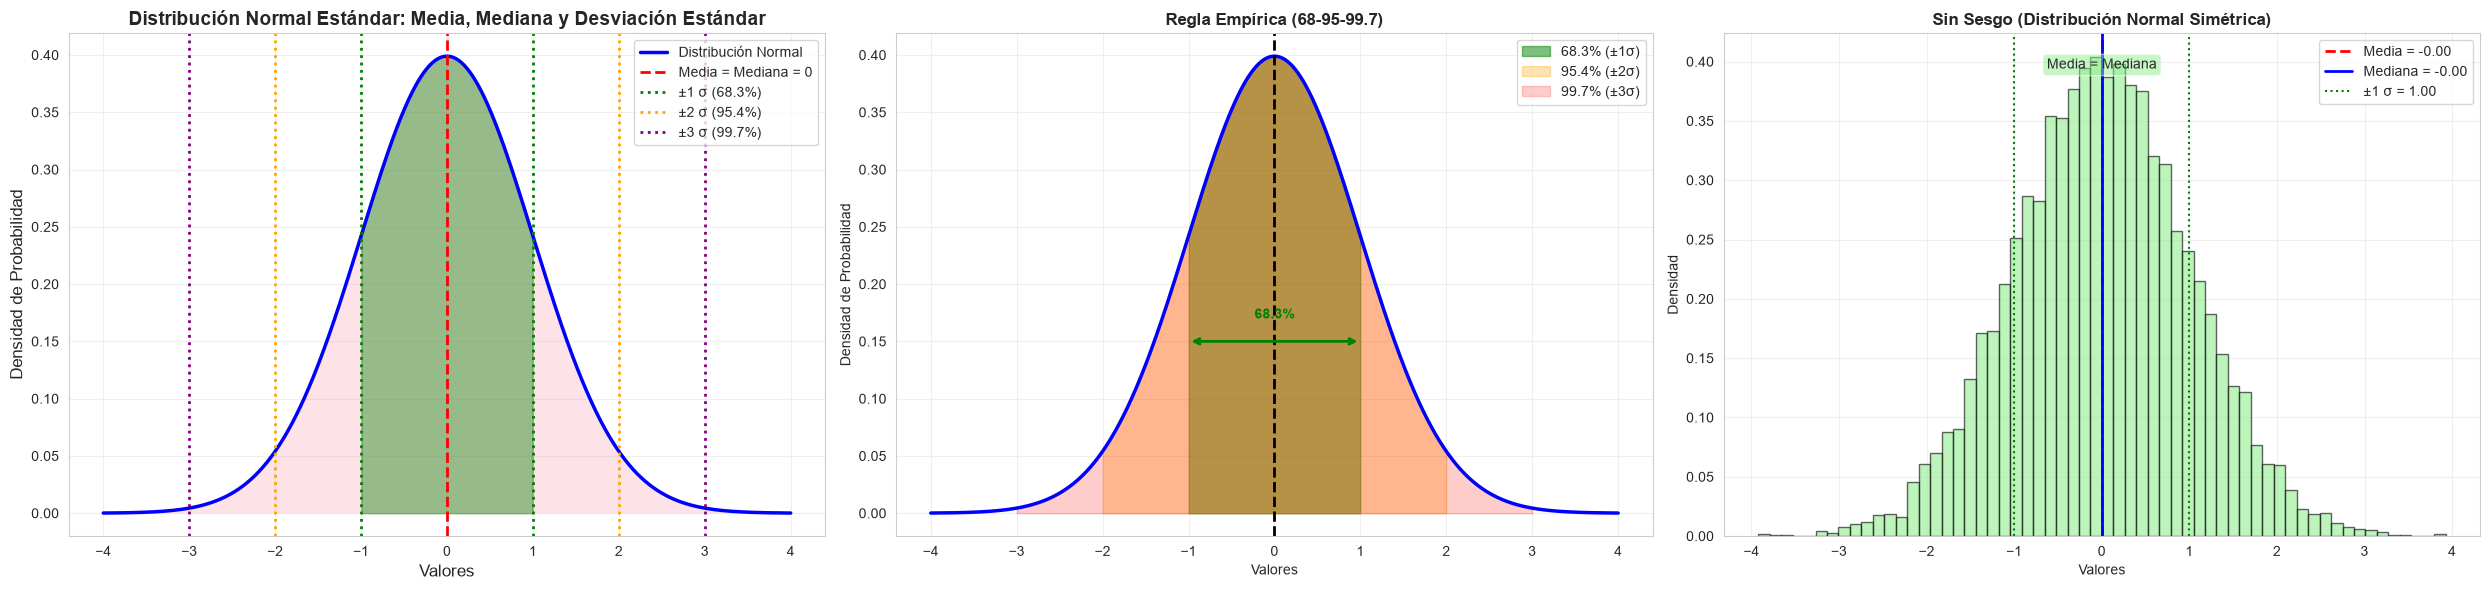

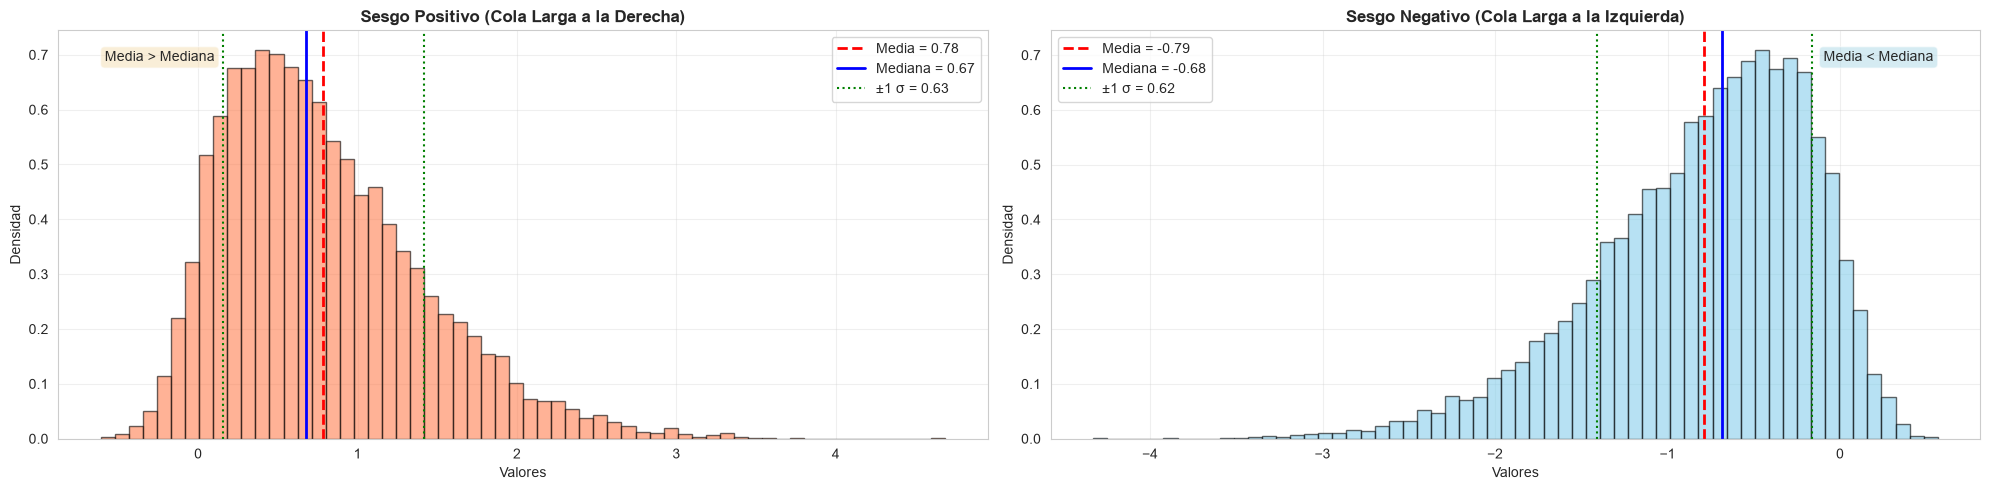

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# =============================================================================
# FIGURA 1: Distribución Normal Estándar con Media, Mediana y Desviación Estándar
# =============================================================================
fig, ax = plt.subplots(1,3, figsize=(25, 6))
ax1, ax2,ax3 = ax

mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

ax1.plot(x, y, 'b-', linewidth=2.5, label='Distribución Normal')
ax1.fill_between(x, y, alpha=0.2)

# Media y Mediana (son iguales en distribución normal)
ax1.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Media = Mediana = {mu}')

# Desviaciones estándar
ax1.axvline(mu + sigma, color='green', linestyle=':', linewidth=2, label=f'±1 σ (68.3%)')
ax1.axvline(mu - sigma, color='green', linestyle=':', linewidth=2)
ax1.axvline(mu + 2*sigma, color='orange', linestyle=':', linewidth=2, label=f'±2 σ (95.4%)')
ax1.axvline(mu - 2*sigma, color='orange', linestyle=':', linewidth=2)
ax1.axvline(mu + 3*sigma, color='purple', linestyle=':', linewidth=2, label=f'±3 σ (99.7%)')
ax1.axvline(mu - 3*sigma, color='purple', linestyle=':', linewidth=2)

# Sombrear área de 1 desviación estándar
x_fill = x[(x >= mu - sigma) & (x <= mu + sigma)]
y_fill = stats.norm.pdf(x_fill, mu, sigma)
ax1.fill_between(x_fill, y_fill, alpha=0.4, color='green')

ax1.set_title('Distribución Normal Estándar: Media, Mediana y Desviación Estándar', fontsize=14, fontweight='bold')
ax1.set_xlabel('Valores', fontsize=12)
ax1.set_ylabel('Densidad de Probabilidad', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)


# =============================================================================
# Efecto de la Desviación Estándar en la Distribución Normal
# =============================================================================
# Regla empírica (68-95-99.7)
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

ax2.plot(x, y, 'b-', linewidth=2.5)

# 68.3% (±1σ)
x1 = x[(x >= mu - sigma) & (x <= mu + sigma)]
y1 = stats.norm.pdf(x1, mu, sigma)
ax2.fill_between(x1, y1, alpha=0.5, color='green', label='68.3% (±1σ)')

# 95.4% (±2σ)
x2 = x[(x >= mu - 2*sigma) & (x <= mu + 2*sigma)]
y2 = stats.norm.pdf(x2, mu, sigma)
ax2.fill_between(x2, y2, alpha=0.3, color='orange', label='95.4% (±2σ)')

# 99.7% (±3σ)
x3 = x[(x >= mu - 3*sigma) & (x <= mu + 3*sigma)]
y3 = stats.norm.pdf(x3, mu, sigma)
ax2.fill_between(x3, y3, alpha=0.2, color='red', label='99.7% (±3σ)')

ax2.axvline(mu, color='black', linestyle='--', linewidth=2)
ax2.set_title('Regla Empírica (68-95-99.7)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Valores')
ax2.set_ylabel('Densidad de Probabilidad')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Anotaciones
ax2.annotate('', xy=(mu-sigma, 0.15), xytext=(mu+sigma, 0.15),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax2.text(mu, 0.17, '68.3%', ha='center', fontsize=10, color='green', fontweight='bold')


# 2.3: Distribución Normal (sin sesgo) -----------------------------------
data_normal = np.random.normal(0, 1, 10000)
ax3.hist(data_normal, bins=60, density=True, alpha=0.6, color='lightgreen', edgecolor='black')

mean_n = np.mean(data_normal)
median_n = np.median(data_normal)
std_n = np.std(data_normal)

ax3.axvline(mean_n, color='red', linestyle='--', linewidth=2, label=f'Media = {mean_n:.2f}')
ax3.axvline(median_n, color='blue', linestyle='-', linewidth=2, label=f'Mediana = {median_n:.2f}')
ax3.axvline(mean_n + std_n, color='green', linestyle=':', linewidth=1.5)
ax3.axvline(mean_n - std_n, color='green', linestyle=':', linewidth=1.5, label=f'±1 σ = {std_n:.2f}')

ax3.set_title('Sin Sesgo (Distribución Normal Simétrica)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Valores')
ax3.set_ylabel('Densidad')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.text(0.5, 0.95, 'Media = Mediana', transform=ax3.transAxes, 
         fontsize=10, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))


plt.tight_layout()
plt.show()
# =============================================================================
# FIGURA 2: Comparación de Distribuciones con Diferentes Sesgos
# =============================================================================
fig, axes = plt.subplots(1,2,figsize=(20, 5))

# 2.1: Distribución con sesgo positivo (cola larga a la derecha)
ax1 = axes[0]
data_right = stats.skewnorm.rvs(5, size=10000)
ax1.hist(data_right, bins=60, density=True, alpha=0.6, color='coral', edgecolor='black')

mean_r = np.mean(data_right)
median_r = np.median(data_right)
std_r = np.std(data_right)

ax1.axvline(mean_r, color='red', linestyle='--', linewidth=2, label=f'Media = {mean_r:.2f}')
ax1.axvline(median_r, color='blue', linestyle='-', linewidth=2, label=f'Mediana = {median_r:.2f}')
ax1.axvline(mean_r + std_r, color='green', linestyle=':', linewidth=1.5)
ax1.axvline(mean_r - std_r, color='green', linestyle=':', linewidth=1.5, label=f'±1 σ = {std_r:.2f}')

ax1.set_title('Sesgo Positivo (Cola Larga a la Derecha)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Valores')
ax1.set_ylabel('Densidad')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, 'Media > Mediana', transform=ax1.transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2.2: Distribución con sesgo negativo (cola larga a la izquierda)
ax2 = axes[1]
data_left = stats.skewnorm.rvs(-5, size=10000)
ax2.hist(data_left, bins=60, density=True, alpha=0.6, color='skyblue', edgecolor='black')

mean_l = np.mean(data_left)
median_l = np.median(data_left)
std_l = np.std(data_left)

ax2.axvline(mean_l, color='red', linestyle='--', linewidth=2, label=f'Media = {mean_l:.2f}')
ax2.axvline(median_l, color='blue', linestyle='-', linewidth=2, label=f'Mediana = {median_l:.2f}')
ax2.axvline(mean_l + std_l, color='green', linestyle=':', linewidth=1.5)
ax2.axvline(mean_l - std_l, color='green', linestyle=':', linewidth=1.5, label=f'±1 σ = {std_l:.2f}')

ax2.set_title('Sesgo Negativo (Cola Larga a la Izquierda)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Valores')
ax2.set_ylabel('Densidad')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.text(0.95, 0.95, 'Media < Mediana', transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## Estadísticos de Variables Categóricas

**Métricas:**
- **unique (cardinalidad)**: Cuántas categorías existen
- **top (moda)**: Categoría más frecuente
- **freq**: Frecuencia de la moda

**Cardinalidad:**
- Baja (≤10): ideal | Media (10-50): revisar | Alta (>50): agrupar

**Concentración (Top 3):**
- \> 80%: ALTA (pocas categorías dominan)
- 50-80%: MODERADA
- < 50%: BAJA (muy dispersa)

In [9]:
# ESTADÍSTICOS DESCRIPTIVOS - VARIABLES CATEGÓRICAS
desc_cat = df.describe(include='object')
desc_cat

,region,categoria,canal,metodo_pago
count,1515,1515,1515,1500
unique,5,5,3,4
top,Metropolitana,Ropa,Tienda Física,Transferencia
freq,530,386,780,402


In [10]:
# Análisis detallado por variable categórica

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col.upper()}")
    print("-" * 70)
    
    freq = df[col].value_counts()
    freq_pct = df[col].value_counts(normalize=True) * 100
    nunique = df[col].nunique()
    nmissing = df[col].isnull().sum()
    
    print(f"Cardinalidad: {nunique} categorías únicas")
    print(f"Valores nulos: {nmissing} ({nmissing/len(df)*100:.1f}%)")
    
    # Análisis de concentración
    top3_pct = freq_pct.head(3).sum()
    if top3_pct > 80:
        concentracion = "ALTA - Dataset dominado por pocas categorías"
    elif top3_pct > 50:
        concentracion = "MODERADA - Distribución relativamente balanceada"
    else:
        concentracion = "BAJA - Distribución dispersa"
    
    print(f"Concentración: {concentracion}")
    
    print(f"\nTop 5 categorías:")
    print(f"{'Categoría':<20} {'Frecuencia':>12} {'Porcentaje':>12} {'Visualización':<15}")
    print("-" * 60)
    
    for i, (cat, count) in enumerate(freq.head(5).items(), 1):
        pct = freq_pct[cat]
        barra = int(pct / 5) * "█"
        print(f"{str(cat):<20} {count:>12} {pct:>11.1f}% {barra:<15}")
    
    if len(freq) > 5:
        otros_count = freq.iloc[5:].sum()
        otros_pct = freq_pct.iloc[5:].sum()
        print(f"{'... Otras '+str(len(freq)-5):<20} {otros_count:>12} {otros_pct:>11.1f}%")



REGION
----------------------------------------------------------------------
Cardinalidad: 5 categorías únicas
Valores nulos: 0 (0.0%)
Concentración: MODERADA - Distribución relativamente balanceada

Top 5 categorías:
Categoría              Frecuencia   Porcentaje Visualización  
------------------------------------------------------------
Metropolitana                 530        35.0% ██████         
Valparaíso                    312        20.6% ████           
Biobío                        259        17.1% ███            
Araucanía                     249        16.4% ███            
Antofagasta                   165        10.9% ██             

CATEGORIA
----------------------------------------------------------------------
Cardinalidad: 5 categorías únicas
Valores nulos: 0 (0.0%)
Concentración: MODERADA - Distribución relativamente balanceada

Top 5 categorías:
Categoría              Frecuencia   Porcentaje Visualización  
-------------------------------------------------------

## Detección de Problemas de Calidad

**1. Valores Faltantes**
**Decisiones:**
- < 1%: Eliminar o imputar
- 1-5%: Investigar patrón
- \> 5%: Problema serio, investigar con negocio

**2. Duplicados**
- ¿Errores de carga o transacciones reales?
- **Acción:** Revisión manual antes de eliminar

**3. Valores Fuera de Rango**
**Ejemplos:**
- Cantidades negativas
- Precios en cero
- Descuentos > 100%

**Indica:** Errores de entrada, problemas de sistema o datos corruptos

**4. Inconsistencias Categóricas**
**Problemas típicos:**
- Mayúsculas/minúsculas: "Santiago" vs "santiago"
- Espacios extra: "Tarjeta " vs "Tarjeta"
- Abreviaturas: "Stgo" vs "Santiago"

**Solución:** Normalizar (minúsculas, trim, unificar)

In [11]:
# ANÁLISIS DE CALIDAD DE DATOS  ---------------------------------------------------

# 1. Valores faltantes
print("\n1. VALORES FALTANTES")
print("-" * 70)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "Columna": missing.index,
    "Valores Faltantes": missing.values,
    "Porcentaje": missing_pct.values,
}).sort_values("Valores Faltantes", ascending=False)

print(missing_df[missing_df["Valores Faltantes"] > 0].to_string(index=False))

total_missing = missing.sum()
if total_missing == 0:
    print("✓ NO HAY VALORES FALTANTES en el dataset")
else:
    print(f"\n⚠ Total de valores faltantes: {total_missing:,}")
    print(f"  → Impacto: {(total_missing / df.size)*100:.2f}% del dataset completo")

# 2. Duplicados
print("\n2. DUPLICADOS")
print("-" * 70)
duplicados = df.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados}")

if duplicados == 0:
    print("✓ No hay filas completamente duplicadas")
else:
    print(f"⚠ {duplicados} filas duplicadas detectadas")
    print("  → Revisión manual recomendada para validar si son reales o errores")

# 3. Valores fuera de rango esperado
print("\n3. VALORES FUERA DE RANGO ESPERADO")
print("-" * 70)

validaciones = {
    "cantidad": {"min": 1, "max": 1000, "desc": "Cantidad de unidades"},
    "precio_unitario": {"min": 1000, "max": 10000000, "desc": "Precio unitario (CLP)"},
    "venta_total": {"min": 1, "max": 100000000, "desc": "Venta total (CLP)"},
    "descuento_porcentaje": {"min": 0, "max": 100, "desc": "Descuento (%)"},
    "venta_neta": {"min": 1, "max": 100000000, "desc": "Venta neta (CLP)"},
    "satisfaccion": {"min": 1, "max": 5, "desc": "Satisfacción (escala 1-5)"},
}

for col, validacion in validaciones.items():
    if col not in df.columns:
        continue
    
    fuera_min = (df[col] < validacion["min"]).sum()
    fuera_max = (df[col] > validacion["max"]).sum()
    fuera_total = fuera_min + fuera_max
    
    if fuera_total == 0:
        print(f"✓ {validacion['desc']}: {len(df)} valores en rango válido")
    else:
        print(f"⚠ {validacion['desc']}: {fuera_total} valores FUERA de rango")
        if fuera_min > 0:
            print(f"  → {fuera_min} por debajo de {validacion['min']}")
        if fuera_max > 0:
            print(f"  → {fuera_max} por encima de {validacion['max']}")

# 4. Inconsistencias categóricas
print("\n4. INCONSISTENCIAS EN CATEGORÍAS")
print("-" * 70)

categorias_a_revisar = ["region", "categoria", "canal", "metodo_pago"]

for col in categorias_a_revisar:
    if col not in df.columns:
        continue
    
    valores_unicos = df[col].unique()
    print(f"\n{col.upper()}:")
    print(f"  Valores únicos: {', '.join(str(v) for v in valores_unicos)}")
    
    # Detectar posibles duplicados (mayúsculas, espacios extra, etc.)
    valores_str = [str(v).strip().lower() for v in df[col].unique()]
    if len(valores_str) != len(set(valores_str)):
        print(f"  ⚠ POSIBLE INCONSISTENCIA DETECTADA")
        print(f"    → Revisar mayúsculas, espacios, caracteres especiales")


1. VALORES FALTANTES
----------------------------------------------------------------------
             Columna  Valores Faltantes  Porcentaje
descuento_porcentaje                 20        1.32
         metodo_pago                 15        0.99
        satisfaccion                 15        0.99

⚠ Total de valores faltantes: 50
  → Impacto: 0.25% del dataset completo

2. DUPLICADOS
----------------------------------------------------------------------
Filas duplicadas exactas: 15
⚠ 15 filas duplicadas detectadas
  → Revisión manual recomendada para validar si son reales o errores

3. VALORES FUERA DE RANGO ESPERADO
----------------------------------------------------------------------
✓ Cantidad de unidades: 1515 valores en rango válido
✓ Precio unitario (CLP): 1515 valores en rango válido
✓ Venta total (CLP): 1515 valores en rango válido
✓ Descuento (%): 1515 valores en rango válido
✓ Venta neta (CLP): 1515 valores en rango válido
✓ Satisfacción (escala 1-5): 1515 valores en rang

## Resumen de Calidad de Datos y Recomendaciones

In [12]:
print("\n" + "=" * 70)
print("RESUMEN DE CALIDAD DE DATOS - RECOMENDACIONES")
print("=" * 70)

issues = []

# Recopilar issues
if df.isnull().sum().sum() > 0:
    issues.append(f"⚠ Valores faltantes: {df.isnull().sum().sum():,} celdas")

if df.duplicated().sum() > 0:
    issues.append(f"⚠ Filas duplicadas: {df.duplicated().sum()}")

# Validar tipos de datos
for col in df.select_dtypes(include=["object"]).columns:
    if df[col].nunique() > 100 and col not in ["cliente_id"]:
        issues.append(f"⚠ Cardinalidad alta en '{col}': {df[col].nunique()} valores")

if len(issues) == 0:
    print("\n✓ DATASET EN EXCELENTE ESTADO")
    print("  → No se detectaron problemas críticos de calidad")
    print("  → Proceder con análisis exploratorio")
else:
    print("\nProblemas detectados:")
    for issue in issues:
        print(f"  {issue}")
    
    print("\nAcciones recomendadas:")
    print("  1. Validar origen de valores faltantes")
    print("  2. Investigar duplicados (¿errores o transacciones reales?)")
    print("  3. Normalizar categorías inconsistentes")
    print("  4. Capear outliers extremos según contexto de negocio")

print("\n✓ CHECKPOINT 1: Visión general completada")
print("  Estado: LISTO para análisis univariante")


RESUMEN DE CALIDAD DE DATOS - RECOMENDACIONES

Problemas detectados:
  ⚠ Valores faltantes: 50 celdas
  ⚠ Filas duplicadas: 15

Acciones recomendadas:
  1. Validar origen de valores faltantes
  2. Investigar duplicados (¿errores o transacciones reales?)
  3. Normalizar categorías inconsistentes
  4. Capear outliers extremos según contexto de negocio

✓ CHECKPOINT 1: Visión general completada
  Estado: LISTO para análisis univariante


# U6.04. Análisis univariante y distribuciones 

In [26]:
# CONFIGURACIÓN Y CARGA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.precision', 2)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")
sns.set_palette("husl")

# Cargar datos
df = pd.read_csv('ventas_retail_2024.csv', parse_dates=['fecha'])

## Herramientas para Analizar Distribuciones

> **Histograma**

**Qué muestra:** Frecuencia de rangos de valores
**Revela:** Forma (normal/sesgada/bimodal), concentración, extremos
**Tip:** Superponer media y mediana para detectar sesgo

> **Boxplot (Diagrama de Caja)**

**Estructura:**
- Caja = 50% central (Q1 a Q3)
- Línea interna = Mediana
- Bigotes = hasta 1.5 × IQR
- Puntos fuera = Outliers

**Ventaja:** Ultra-compacto, perfecto para comparar grupos

> **Violin Plot**

**Qué agrega:** Densidad (ancho = concentración)
**Revela:** Multimodalidad (múltiples picos)
**Cuándo usar:** Para detectar subgrupos ocultos

> **KDE (Kernel Density Estimation)**

**Qué es:** Histograma suavizado (curva continua)
**Revela:** Probabilidad, múltiples modas
**Cuándo usar:** Presentaciones elegantes, análisis fino de modas


## Análisis Univariante de Variables Numéricas Continuas

> Panel de 4 Gráficos Simultáneos

1. Histograma (con media/mediana)
2. Boxplot (outliers)
3. Violin plot (densidad)
4. KDE (probabilidad)

> Interpretación de Asimetría

- **> 1**: Sesgo positivo fuerte (cola derecha, valores altos raros)
- **> 0.5**: Sesgo positivo moderado
- **< -1**: Sesgo negativo fuerte (cola izquierda, valores bajos raros)
- **< -0.5**: Sesgo negativo moderado
- **≈ 0**: Distribución simétrica

> ⚠️ Decisión Clave

**Si Media ≠ Mediana** → Distribución sesgada → **USA MEDIANA** en reportes


ANÁLISIS UNIVARIANTE - VARIABLES NUMÉRICAS

VENTA NETA (MÉTRICA PRINCIPAL)

--- Estadísticos Descriptivos ---
Media                     347,115.02
Mediana                   252,647.73
Moda                       30,231.51
Desv. Estándar            341,031.09
Mínimo                      5,340.38
Q1 (25%)                  115,317.22
Q2 (50%)                  252,647.73
Q3 (75%)                  498,233.50
Máximo                  5,946,290.48
Rango                   5,940,950.10
IQR                       382,916.28
CV (%)                         98.25
Asimetría                       5.08
Curtosis                       61.74

--- Interpretación de la Distribución ---
✓ SESGO POSITIVO FUERTE (cola derecha)
  Mayoría de valores bajos, pocos muy altos


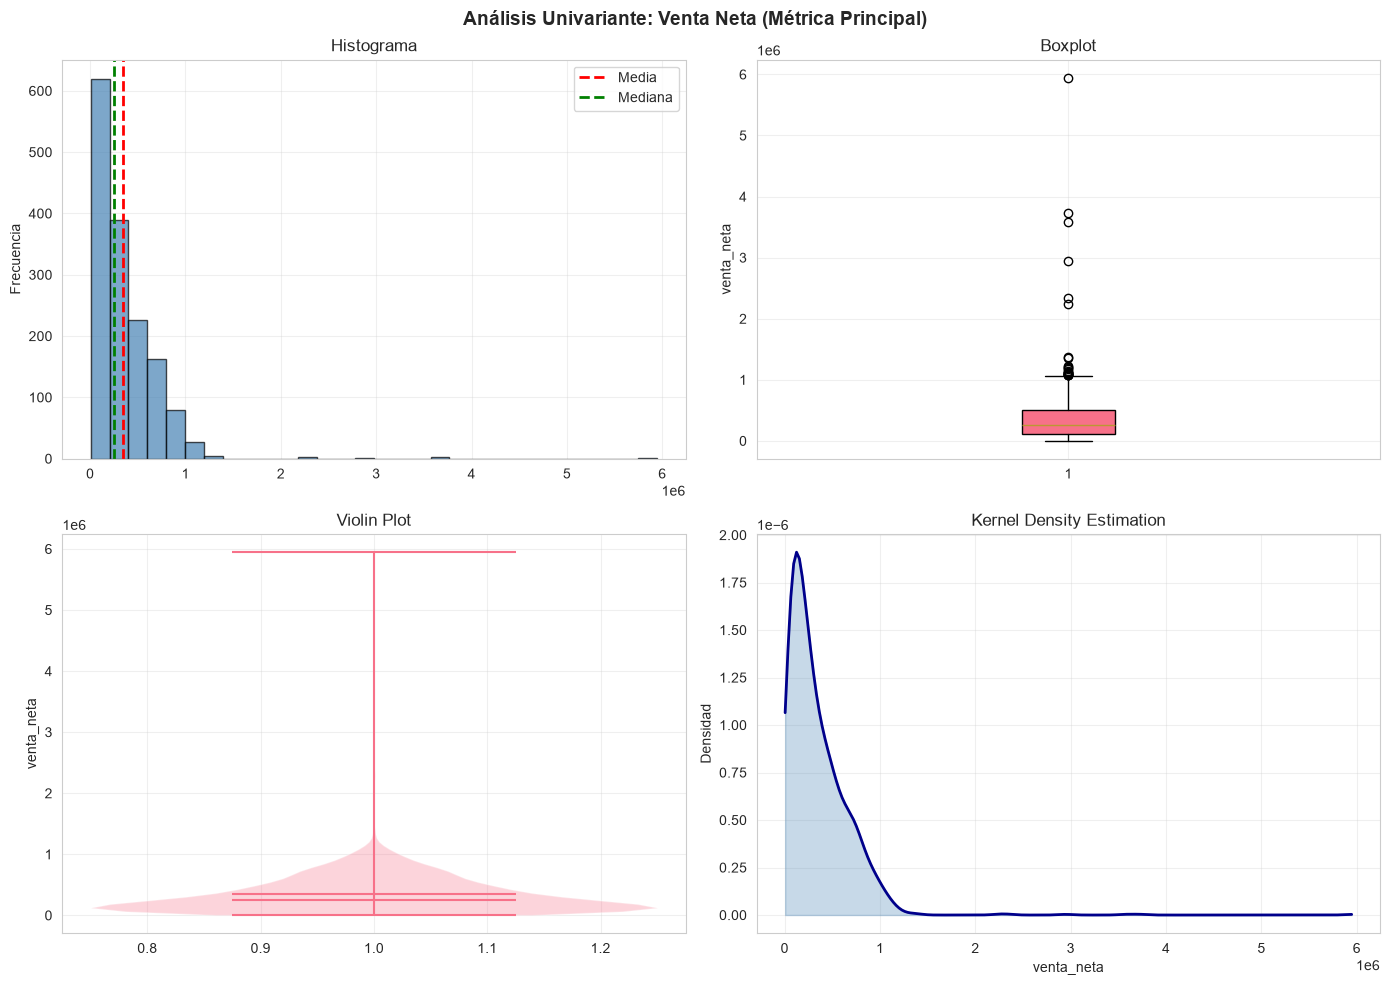


PRECIO UNITARIO

--- Estadísticos Descriptivos ---
Media                      75,171.74
Mediana                    74,736.53
Moda                        6,211.43
Desv. Estándar             41,278.97
Mínimo                      5,034.95
Q1 (25%)                   39,343.51
Q2 (50%)                   74,736.53
Q3 (75%)                  109,443.59
Máximo                    149,841.18
Rango                     144,806.24
IQR                        70,100.09
CV (%)                         54.91
Asimetría                       0.05
Curtosis                       -1.16

--- Interpretación de la Distribución ---
✓ DISTRIBUCIÓN RELATIVAMENTE SIMÉTRICA


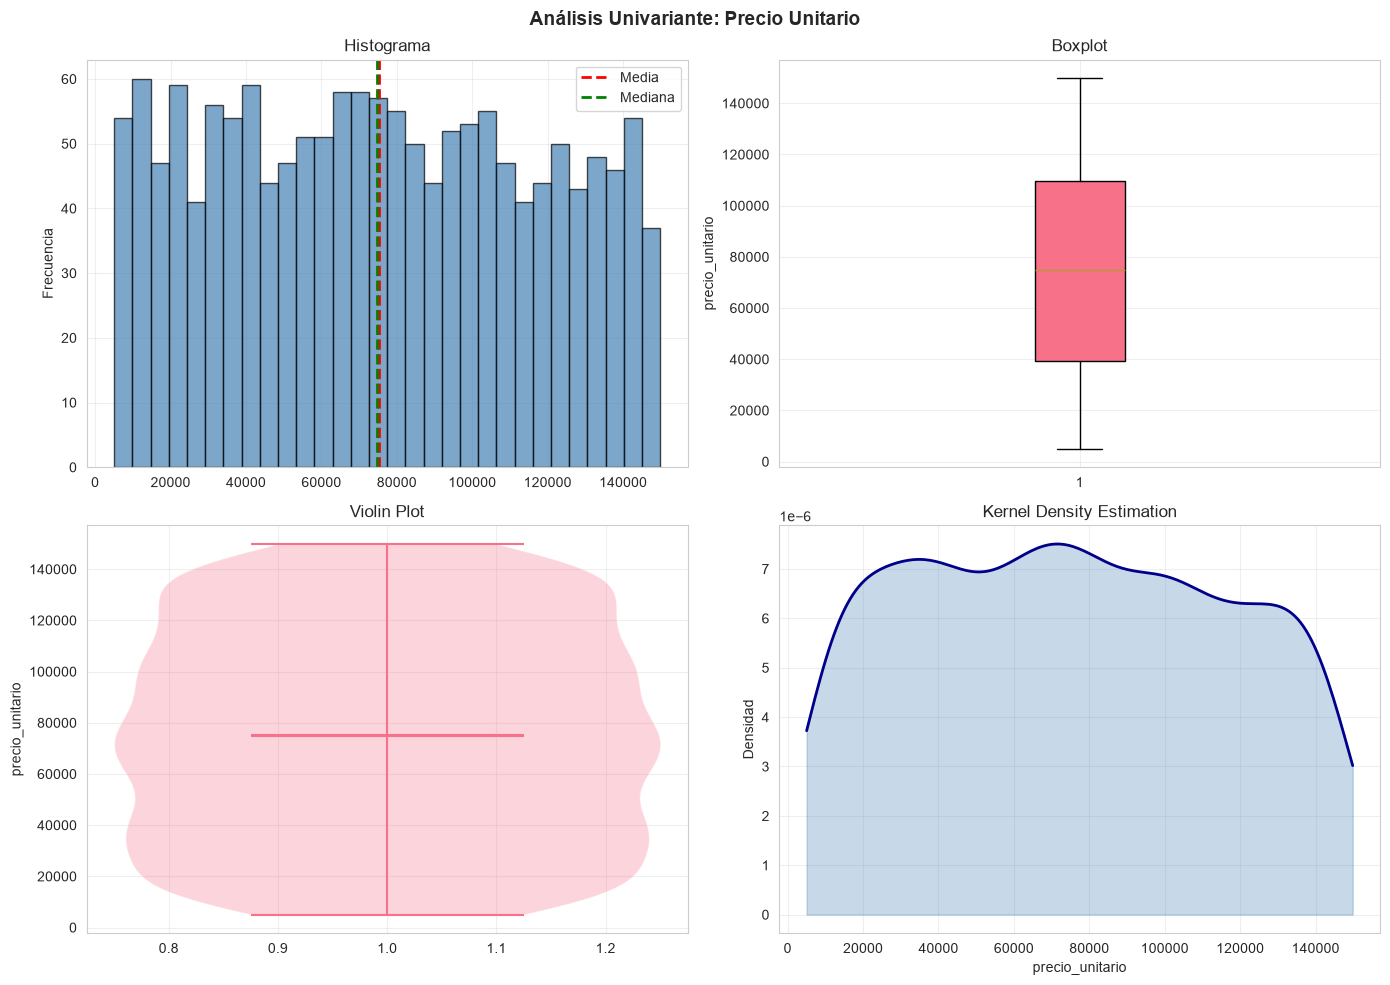

{'Media': np.float64(75171.73528555513),
 'Mediana': np.float64(74736.53317222401),
 'Moda': np.float64(6211.432104960093),
 'Desv. Estándar': np.float64(41278.974493477705),
 'Mínimo': np.float64(5034.94567934451),
 'Q1 (25%)': np.float64(39343.505391703555),
 'Q2 (50%)': np.float64(74736.53317222401),
 'Q3 (75%)': np.float64(109443.59375072068),
 'Máximo': np.float64(149841.18146564614),
 'Rango': np.float64(144806.23578630164),
 'IQR': np.float64(70100.08835901713),
 'CV (%)': np.float64(54.912892906717026),
 'Asimetría': np.float64(0.054613435573403236),
 'Curtosis': np.float64(-1.1612429203222547)}

In [39]:
import numpy as np
from scipy import stats

print("=" * 70)
print("ANÁLISIS UNIVARIANTE - VARIABLES NUMÉRICAS")
print("=" * 70)

# Definir variables a analizar
vars_continuas = [
    "precio_unitario",
    "venta_total",
    "descuento_monto",
    "venta_neta",
    "descuento_porcentaje",
]

def analizar_variable_numerica(df, variable, titulo=None):
    """Análisis completo de variable numérica"""
    
    if titulo is None:
        titulo = variable
    
    print(f"\n{titulo.upper()}")
    print("=" * 70)
    
    # Limpiar nulos
    data = df[variable].dropna()
    
    # Estadísticos
    stats_dict = {
        "Media": data.mean(),
        "Mediana": data.median(),
        "Moda": data.mode().values[0] if len(data.mode()) > 0 else np.nan,
        "Desv. Estándar": data.std(),
        "Mínimo": data.min(),
        "Q1 (25%)": data.quantile(0.25),
        "Q2 (50%)": data.quantile(0.50),
        "Q3 (75%)": data.quantile(0.75),
        "Máximo": data.max(),
        "Rango": data.max() - data.min(),
        "IQR": data.quantile(0.75) - data.quantile(0.25),
        "CV (%)": (data.std() / data.mean()) * 100 if data.mean() != 0 else np.nan,
        "Asimetría": data.skew(),
        "Curtosis": data.kurtosis(),
    }
    
    print("\n--- Estadísticos Descriptivos ---")
    for stat, value in stats_dict.items():
        if pd.notna(value):
            if "CV" in stat or "Asimetría" in stat or "Curtosis" in stat:
                print(f"{stat:<20} {value:>15.2f}")
            else:
                print(f"{stat:<20} {value:>15,.2f}")
    
    # Interpretación de forma
    print("\n--- Interpretación de la Distribución ---")
    
    asimetria = stats_dict["Asimetría"]
    if asimetria > 1:
        print("✓ SESGO POSITIVO FUERTE (cola derecha)")
        print("  Mayoría de valores bajos, pocos muy altos")
    elif asimetria > 0.5:
        print("✓ SESGO POSITIVO MODERADO (cola derecha)")
    elif asimetria < -1:
        print("✓ SESGO NEGATIVO FUERTE (cola izquierda)")
        print("  Mayoría de valores altos, pocos muy bajos")
    elif asimetria < -0.5:
        print("✓ SESGO NEGATIVO MODERADO (cola izquierda)")
    else:
        print("✓ DISTRIBUCIÓN RELATIVAMENTE SIMÉTRICA")
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Análisis Univariante: {titulo}", fontsize=14, fontweight="bold")
    
    # Histograma
    axes[0, 0].hist(data, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    axes[0, 0].axvline(data.mean(), color="red", linestyle="--", linewidth=2, label="Media")
    axes[0, 0].axvline(data.median(), color="green", linestyle="--", linewidth=2, label="Mediana")
    axes[0, 0].set_title("Histograma")
    axes[0, 0].set_ylabel("Frecuencia")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Boxplot
    axes[0, 1].boxplot(data, vert=True, patch_artist=True)
    axes[0, 1].set_title("Boxplot")
    axes[0, 1].set_ylabel(variable)
    axes[0, 1].grid(alpha=0.3)
    
    # Violin plot
    parts = axes[1, 0].violinplot(data, vert=True, showmeans=True, showmedians=True)
    axes[1, 0].set_title("Violin Plot")
    axes[1, 0].set_ylabel(variable)
    axes[1, 0].grid(alpha=0.3)
    
    # KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    axes[1, 1].plot(x_range, kde(x_range), linewidth=2, color="darkblue")
    axes[1, 1].fill_between(x_range, kde(x_range), alpha=0.3, color="steelblue")
    axes[1, 1].set_title("Kernel Density Estimation")
    axes[1, 1].set_xlabel(variable)
    axes[1, 1].set_ylabel("Densidad")
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return stats_dict

# Ejecutar análisis para variable clave
analizar_variable_numerica(df, "venta_neta", "Venta Neta (Métrica Principal)")
analizar_variable_numerica(df, "precio_unitario", "Precio Unitario")

## Detección Sistemática de Outliers

> Método 1: IQR (Tukey) ⭐ Estándar

**Límites:**
- Inferior: Q1 - 1.5 × IQR
- Superior: Q3 + 1.5 × IQR

**Ventaja:** Robusto (no se afecta por outliers extremos)

> Método 2: Z-score

**Criterio:** |Z| > 3 es outlier extremo
**Z = (valor - media) / std**
**Limitación:** Sensible a outliers (usa media y std)

> Método 3: MAD (Median Absolute Deviation)

**Qué es:** Como Z-score pero con mediana
**Cuándo usar:** Cuando hay muchos outliers extremos

> 📋 Recomendaciones por Porcentaje

- **< 1%**: ✓ Conservar, investigar individualmente
- **1-5%**: ⚠ Investigar con negocio, considerar análisis separado
- **> 5%**: ⚠ Revisar distribución, considerar transformación (log, box-cox)



DETECCIÓN DE OUTLIERS: VENTA_NETA

Valores válidos: 1515 transacciones

Método IQR (1.5 × IQR):
  Límite inferior: -459,057.20
  Límite superior: 1,072,607.92
  Outliers detectados: 23
  Porcentaje: 1.52%

Método Z-score (|z| > 3):
  Outliers extremos: 6

Método Z-score moderado (|z| > 2.5):
  Outliers moderados: 10


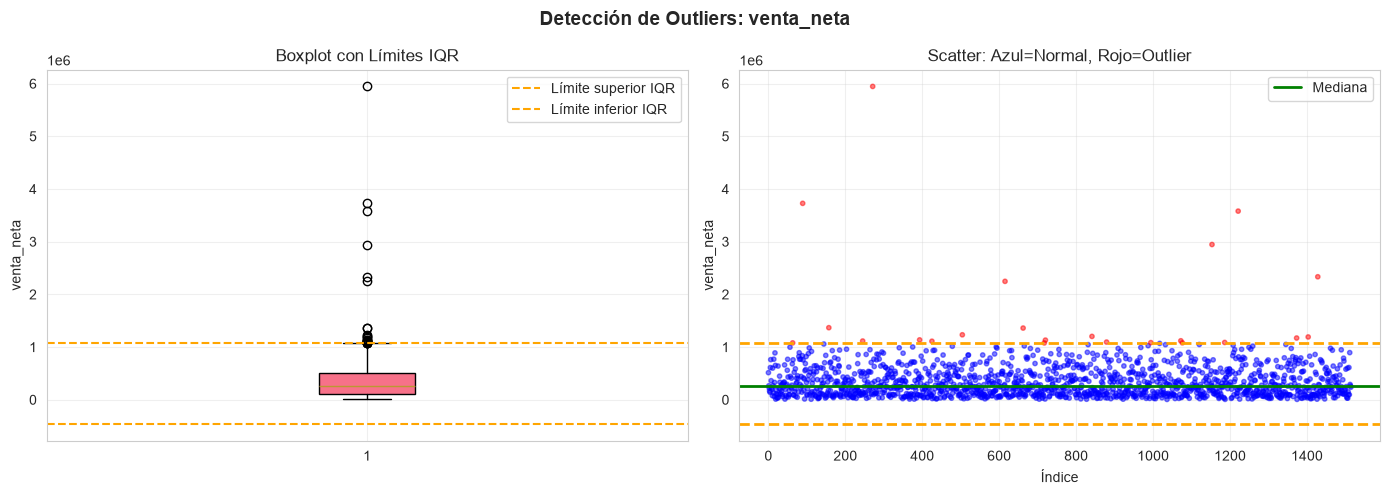


--- RECOMENDACIONES ---
⚠ Outliers moderados (1.52%) - INVESTIGAR
  Validar con área de negocio
  Considerar análisis separado de outliers

DETECCIÓN DE OUTLIERS: PRECIO_UNITARIO

Valores válidos: 1515 transacciones

Método IQR (1.5 × IQR):
  Límite inferior: -65,806.63
  Límite superior: 214,593.73
  Outliers detectados: 0
  Porcentaje: 0.00%

Método Z-score (|z| > 3):
  Outliers extremos: 0

Método Z-score moderado (|z| > 2.5):
  Outliers moderados: 0


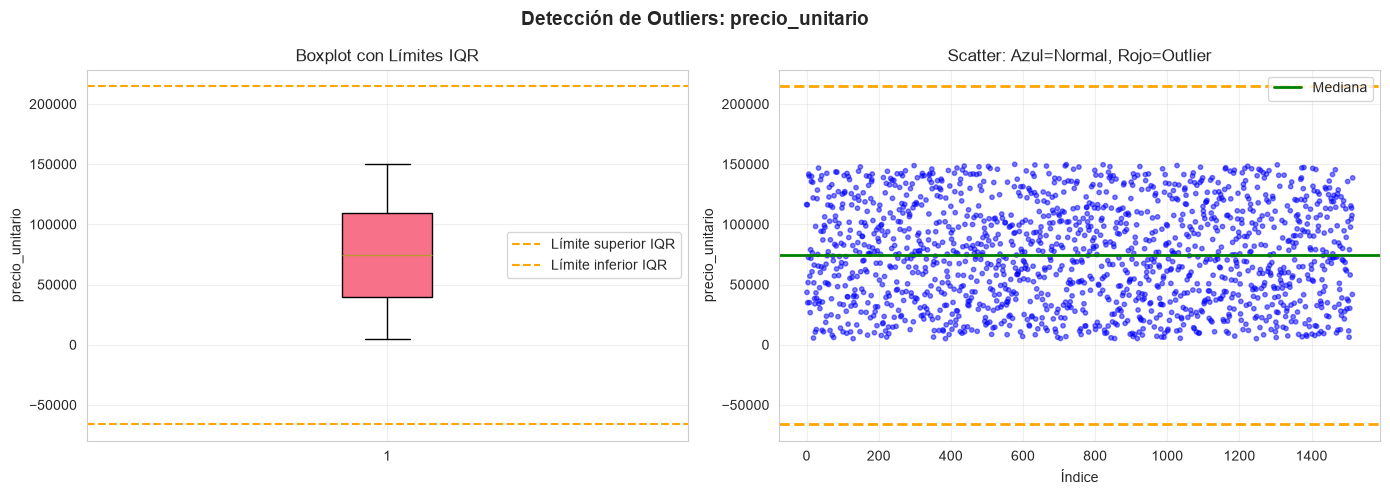


--- RECOMENDACIONES ---
✓ Pocos outliers (0.00%) - CONSERVAR
  Investigar casos extremos individualmente


In [40]:
def detectar_outliers_completo(df, variable):
    """
    Detecta outliers usando tres métodos:
    1. Método IQR (Tukey)
    2. Método Z-score
    3. Método MAD (Median Absolute Deviation)
    """
    
    data = df[variable].dropna()
    
    print(f"\nDETECCIÓN DE OUTLIERS: {variable.upper()}")
    print("=" * 70)
    
    # Método 1: IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_iqr_moderate = data[(data < lower_bound) | (data > upper_bound)]
    
    # Método 2: Z-score (outliers extremos: |z| > 3)
    z_scores = np.abs(stats.zscore(data))
    outliers_zscore = data[z_scores > 3]
    
    # Método 3: Z-score moderado (|z| > 2.5)
    outliers_zscore_moderate = data[z_scores > 2.5]
    
    print(f"\nValores válidos: {len(data)} transacciones")
    print(f"\nMétodo IQR (1.5 × IQR):")
    print(f"  Límite inferior: {lower_bound:,.2f}")
    print(f"  Límite superior: {upper_bound:,.2f}")
    print(f"  Outliers detectados: {len(outliers_iqr_moderate)}")
    print(f"  Porcentaje: {len(outliers_iqr_moderate)/len(data)*100:.2f}%")
    
    print(f"\nMétodo Z-score (|z| > 3):")
    print(f"  Outliers extremos: {len(outliers_zscore)}")
    
    print(f"\nMétodo Z-score moderado (|z| > 2.5):")
    print(f"  Outliers moderados: {len(outliers_zscore_moderate)}")
    
    # Visualización comparativa
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Detección de Outliers: {variable}", fontsize=14, fontweight="bold")
    
    # Boxplot con límites marcados
    axes[0].boxplot(data, vert=True, patch_artist=True)
    axes[0].axhline(upper_bound, color="orange", linestyle="--", label="Límite superior IQR")
    axes[0].axhline(lower_bound, color="orange", linestyle="--", label="Límite inferior IQR")
    axes[0].set_ylabel(variable)
    axes[0].set_title("Boxplot con Límites IQR")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Scatter con colores
    indices = range(len(data))
    colors = ["red" if x in outliers_iqr_moderate.values else "blue" for x in data]
    axes[1].scatter(indices, data, c=colors, alpha=0.5, s=10)
    axes[1].axhline(upper_bound, color="orange", linestyle="--", linewidth=2)
    axes[1].axhline(lower_bound, color="orange", linestyle="--", linewidth=2)
    axes[1].axhline(data.median(), color="green", linestyle="-", linewidth=2, label="Mediana")
    axes[1].set_xlabel("Índice")
    axes[1].set_ylabel(variable)
    axes[1].set_title("Scatter: Azul=Normal, Rojo=Outlier")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Recomendaciones
    pct_outliers = len(outliers_iqr_moderate) / len(data) * 100
    
    print(f"\n--- RECOMENDACIONES ---")
    if pct_outliers < 1:
        print(f"✓ Pocos outliers ({pct_outliers:.2f}%) - CONSERVAR")
        print("  Investigar casos extremos individualmente")
    elif pct_outliers < 5:
        print(f"⚠ Outliers moderados ({pct_outliers:.2f}%) - INVESTIGAR")
        print("  Validar con área de negocio")
        print("  Considerar análisis separado de outliers")
    else:
        print(f"✓ Muchos outliers ({pct_outliers:.2f}%) - REVISAR DISTRIBUCIÓN")
        print("  Posible problema en los datos o distribución no gaussiana")
        print("  Considerar transformación (log, box-cox)")
    
    return {
        "outliers_iqr": outliers_iqr_moderate,
        "outliers_zscore": outliers_zscore,
        "limite_inferior": lower_bound,
        "limite_superior": upper_bound,
    }

# Detectar outliers en variables clave
outliers_venta = detectar_outliers_completo(df, "venta_neta")
outliers_precio = detectar_outliers_completo(df, "precio_unitario")

## Análisis de Variables Discretas

**Diferencia:** Solo valores enteros (1, 2, 3... no 2.37)

**Visualización:** Gráfico de barras (barras NO se tocan)

**Ejemplo:** Cantidad de productos vendidos
- Moda: Valor más frecuente
- Outliers: Cantidades extraordinariamente altas (compras corporativas vs retail)


ANÁLISIS DE VARIABLE DISCRETA: CANTIDAD

Estadísticos:
Moda (valor más frecuente)                2.00
Media                                     4.97
Mediana                                   5.00
Desv. Estándar                            2.61
Mínimo                                    1.00
Máximo                                    9.00


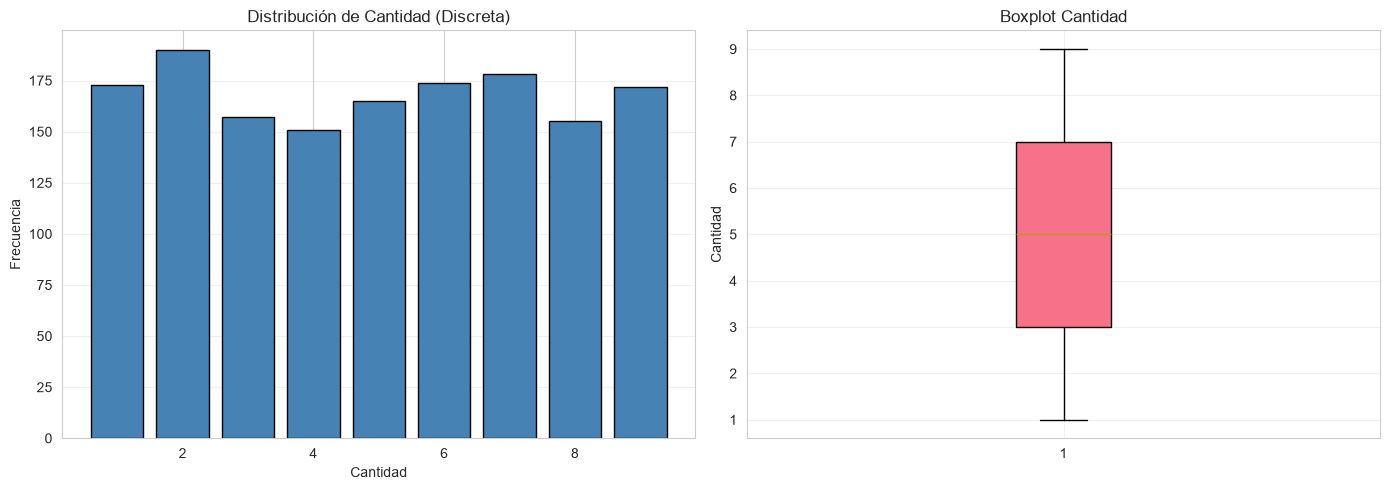


Interpretación:
- Rango: 1 a 9 unidades
- Cantidad típica: 5 unidades (mediana)
- Variabilidad: 52.4% (CV)


In [41]:
print("\n" + "=" * 70)
print("ANÁLISIS DE VARIABLE DISCRETA: CANTIDAD")
print("=" * 70)

cantidad_stats = {
    "Moda (valor más frecuente)": df["cantidad"].mode().values[0],
    "Media": df["cantidad"].mean(),
    "Mediana": df["cantidad"].median(),
    "Desv. Estándar": df["cantidad"].std(),
    "Mínimo": df["cantidad"].min(),
    "Máximo": df["cantidad"].max(),
}

print("\nEstadísticos:")
for stat, value in cantidad_stats.items():
    print(f"{stat:<35} {value:>10.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot de frecuencias
freq_cantidad = df["cantidad"].value_counts().sort_index()
axes[0].bar(freq_cantidad.index, freq_cantidad.values, edgecolor="black", color="steelblue")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de Cantidad (Discreta)")
axes[0].grid(alpha=0.3, axis="y")

# Boxplot
axes[1].boxplot(df["cantidad"], vert=True, patch_artist=True)
axes[1].set_ylabel("Cantidad")
axes[1].set_title("Boxplot Cantidad")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print(f"- Rango: {cantidad_stats['Mínimo']:.0f} a {cantidad_stats['Máximo']:.0f} unidades")
print(f"- Cantidad típica: {cantidad_stats['Mediana']:.0f} unidades (mediana)")
print(f"- Variabilidad: {(cantidad_stats['Desv. Estándar']/cantidad_stats['Media']*100):.1f}% (CV)")

## Análisis de Variables Ordinales

**Ejemplo:** Satisfacción 1-5

**Tratamiento especial:**
- Calcular distribución de frecuencias
- Asignar etiquetas descriptivas (1=Muy Insatisfecho ... 5=Muy Satisfecho)
- Usar tabla con barras visuales

**Métricas clave:**
- % Satisfechos (4-5): Meta ≥ 80%
- % Insatisfechos (1-2): Alerta si > 15%

**Umbrales de Acción:**
- ≥ 80% satisfechos: ✓ EXCELENTE
- 60-80%: ⚠ BUENO (margen de mejora)
- < 60%: ❌ CRÍTICO (intervención inmediata)


ANÁLISIS DE VARIABLE ORDINAL: SATISFACCIÓN (1-5)

Distribución:
Nivel        Frecuencia   Porcentaje Visualización       
-------------------------------------------------------
1.0 (Muy Insatisfecho)          312        20.8% ████
2.0 (Insatisfecho   )          310        20.7% ████
3.0 (Neutral        )          287        19.1% ███
4.0 (Satisfecho     )          284        18.9% ███
5.0 (Muy Satisfecho )          307        20.5% ████

Métricas agregadas:
- Promedio: 2.98
- Mediana: 3
- % Satisfechos (4-5): 39.0%
- % Insatisfechos (1-2): 41.1%


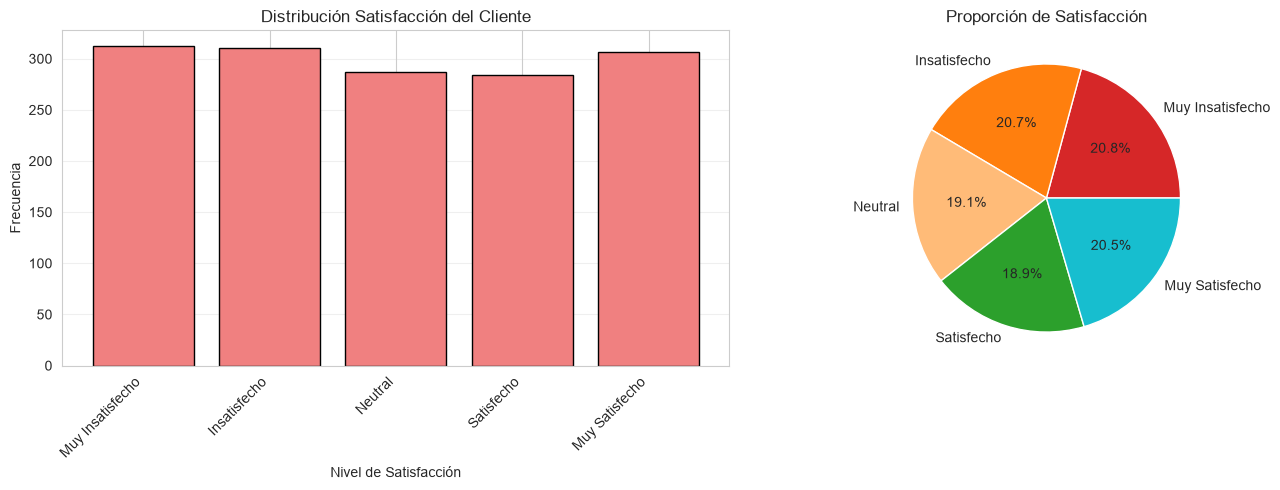


Interpretación:
✓ 39.0% de clientes están satisfechos (4-5)
  Estado: CRÍTICO - Requiere intervención inmediata


In [42]:
print("\n" + "=" * 70)
print("ANÁLISIS DE VARIABLE ORDINAL: SATISFACCIÓN (1-5)")
print("=" * 70)

# Distribución de frecuencias
satisf_freq = df["satisfaccion"].value_counts().sort_index()
satisf_pct = df["satisfaccion"].value_counts(normalize=True).sort_index() * 100

print("\nDistribución:")
print(f"{'Nivel':<10} {'Frecuencia':>12} {'Porcentaje':>12} {'Visualización':<20}")
print("-" * 55)

labels_satisf = {1: "Muy Insatisfecho", 2: "Insatisfecho", 3: "Neutral", 4: "Satisfecho", 5: "Muy Satisfecho"}

for nivel in sorted(satisf_freq.index):
    freq = satisf_freq[nivel]
    pct = satisf_pct[nivel]
    barra = int(pct / 5) * "█"
    print(f"{nivel} ({labels_satisf[nivel]:<15}) {freq:>12} {pct:>11.1f}% {barra}")

# Análisis agregado
satisf_media = df["satisfaccion"].mean()
satisf_mediana = df["satisfaccion"].median()
satisf_pct_altos = (df["satisfaccion"] >= 4).sum() / len(df) * 100

print(f"\nMétricas agregadas:")
print(f"- Promedio: {satisf_media:.2f}")
print(f"- Mediana: {satisf_mediana:.0f}")
print(f"- % Satisfechos (4-5): {satisf_pct_altos:.1f}%")
print(f"- % Insatisfechos (1-2): {(df['satisfaccion'] <= 2).sum() / len(df) * 100:.1f}%")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(satisf_freq.index, satisf_freq.values, color="lightcoral", edgecolor="black")
axes[0].set_xlabel("Nivel de Satisfacción")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución Satisfacción del Cliente")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xticklabels(["Muy Insatisfecho", "Insatisfecho", "Neutral", "Satisfecho", "Muy Satisfecho"], rotation=45, ha="right")
axes[0].grid(alpha=0.3, axis="y")

# Pie chart
colors = ["#d62728", "#ff7f0e", "#ffbb78", "#2ca02c", "#17becf"]
axes[1].pie(satisf_freq.values, labels=[labels_satisf[i] for i in satisf_freq.index], autopct="%1.1f%%", colors=colors)
axes[1].set_title("Proporción de Satisfacción")

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print(f"✓ {satisf_pct_altos:.1f}% de clientes están satisfechos (4-5)")
if satisf_pct_altos >= 80:
    print("  Estado: EXCELENTE - Satisfacción alta consolidada")
elif satisf_pct_altos >= 60:
    print("  Estado: BUENO - Satisfacción aceptable, margen de mejora")
else:
    print("  Estado: CRÍTICO - Requiere intervención inmediata")

## Análisis Temporal

> Validaciones

- **Rango temporal:** Fecha inicio/fin, duración total
- **Densidad:** Transacciones por día
- **Huecos:** ¿Fines de semana sin datos? (¿real o problema?)

> Patrones a Buscar

- **Estacionalidad mensual:** ¿Navidad, Black Friday, verano?
- **Tendencias:** ¿Sube, baja, estable?
- **Cambios de régimen:** ¿Punto donde comportamiento cambia?

> Variables Derivadas Útiles

- year_month (2024-01, 2024-02...)
- day_of_week (Lunes, Martes...)
- is_weekend (Sí/No)
- trimestre (Q1, Q2, Q3, Q4)
- temporada (Verano, Otoño, Invierno, Primavera)

> Visualizaciones

1. **Línea temporal:** Transacciones por día
2. **Barras:** Venta neta por mes



ANÁLISIS TEMPORAL

Cobertura temporal:
- Fecha inicial: 2024-01-01
- Fecha final: 2024-12-30
- Duración: 364 días (1.0 años)
- Transacciones por día: 4.2

Transacciones por mes:
year_month
2024-01    125
2024-02    128
2024-03     98
2024-04    141
2024-05    145
2024-06    130
2024-07    106
2024-08    144
2024-09    121
2024-10    134
2024-11    120
2024-12    123
Freq: M, Name: count, dtype: int64


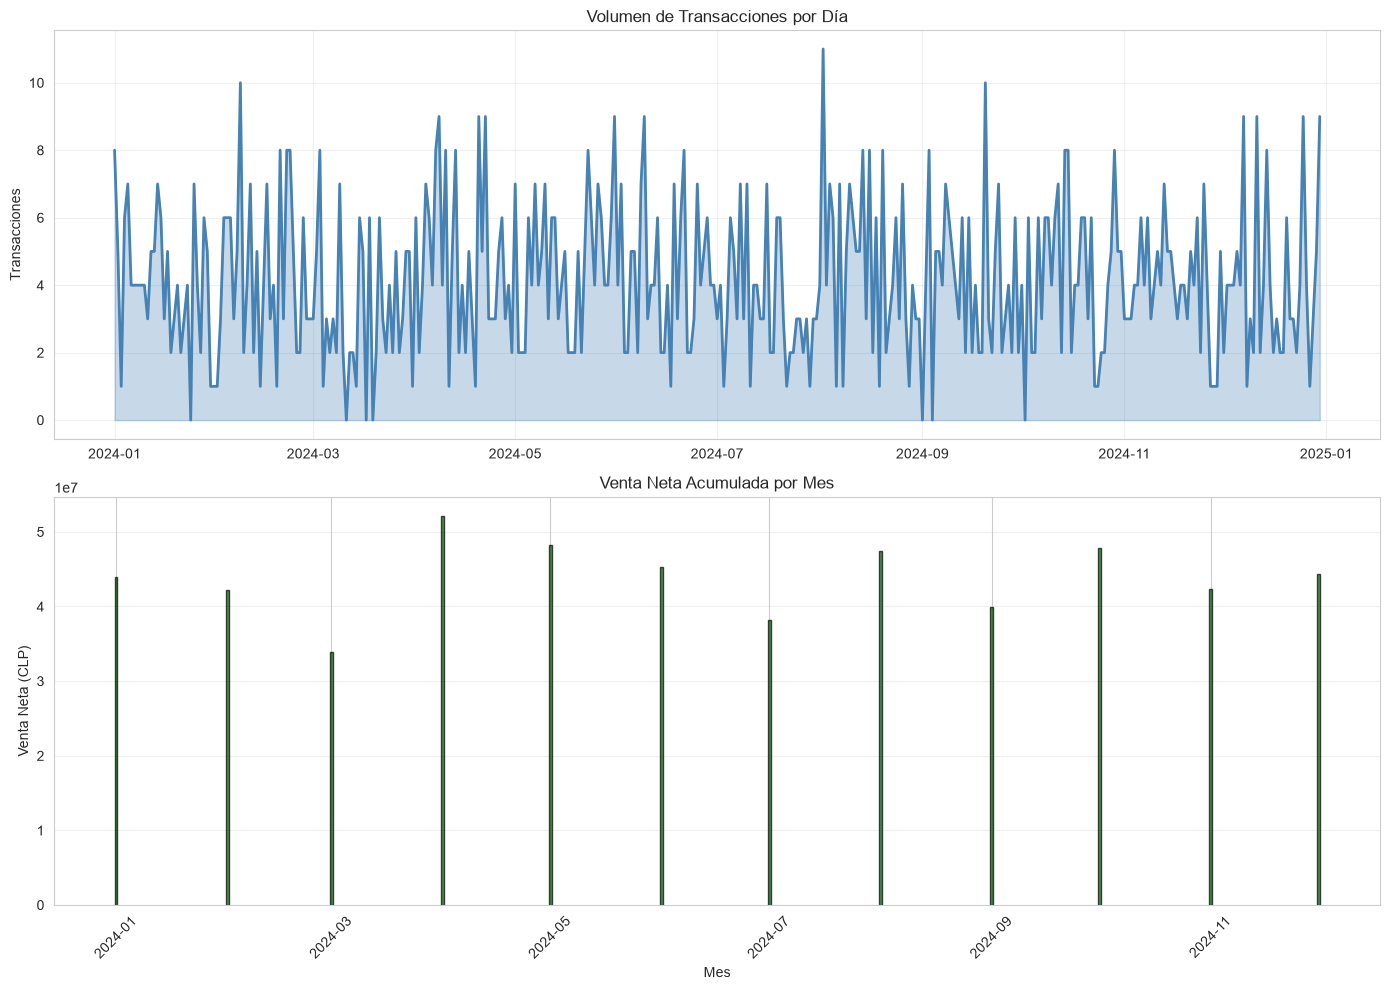


✓ CHECKPOINT 1: Análisis Univariante Completado
  Distribuciones entendidas, outliers identificados
  Listo para análisis bivariante


In [43]:
print("\n" + "=" * 70)
print("ANÁLISIS TEMPORAL")
print("=" * 70)

# Rango temporal
fecha_min = df["fecha"].min()
fecha_max = df["fecha"].max()
dias_totales = (fecha_max - fecha_min).days

print(f"\nCobertura temporal:")
print(f"- Fecha inicial: {fecha_min.strftime('%Y-%m-%d')}")
print(f"- Fecha final: {fecha_max.strftime('%Y-%m-%d')}")
print(f"- Duración: {dias_totales} días ({dias_totales/365:.1f} años)")
print(f"- Transacciones por día: {len(df) / (dias_totales+1):.1f}")

# Transacciones por mes
df["year_month"] = df["fecha"].dt.to_period("M")
transacciones_por_mes = df["year_month"].value_counts().sort_index()

print(f"\nTransacciones por mes:")
print(transacciones_por_mes)

# Visualización temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Transacciones por día
transacciones_por_dia = df.set_index("fecha").resample("D").size()
axes[0].plot(transacciones_por_dia.index, transacciones_por_dia.values, linewidth=2, color="steelblue")
axes[0].fill_between(transacciones_por_dia.index, transacciones_por_dia.values, alpha=0.3, color="steelblue")
axes[0].set_ylabel("Transacciones")
axes[0].set_title("Volumen de Transacciones por Día")
axes[0].grid(alpha=0.3)

# Venta neta por mes
venta_por_mes = df.groupby("year_month")["venta_neta"].sum().astype("float64")
venta_por_mes.index = venta_por_mes.index.to_timestamp()
axes[1].bar(venta_por_mes.index, venta_por_mes.values, color="darkgreen", edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Venta Neta (CLP)")
axes[1].set_title("Venta Neta Acumulada por Mes")
axes[1].grid(alpha=0.3, axis="y")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"\n✓ CHECKPOINT 1: Análisis Univariante Completado")
print(f"  Distribuciones entendidas, outliers identificados")
print(f"  Listo para análisis bivariante")

**⚠️ ERRORES COMUNES A EVITAR**

1. ❌ No detectar outliers → Modelo distorsionado
2. ❌ Usar media cuando deberías usar mediana → Visión falsa
3. ❌ Ignorar forma de distribución → Técnicas inválidas
4. ❌ Comparar períodos sin contexto temporal → Conclusiones falsas

**💡 Regla de Oro:** Un outlier mal manejado puede costar millones en decisiones erróneas.

# U6.05. Análisis bivariante, multivariante y síntesis final

## Relaciones entre Variables Numéricas: Correlación y Regresión

> **Herramientas Clave**

**Scatterplot**: Nube de puntos (X vs Y)
- Tendencia positiva: ↗ (X↑ → Y↑)
- Tendencia negativa: ↘ (X↑ → Y↓)
- Sin relación: puntos dispersos sin patrón

**Correlación de Pearson (r)**
- +1: Relación positiva perfecta
- 0: Sin relación lineal
- -1: Relación negativa perfecta
- **Interpretación fuerza:**
  - |r| ≥ 0.9: MUY FUERTE 🔴
  - |r| ≥ 0.7: FUERTE 🟠
  - |r| ≥ 0.5: MODERADA 🟡
  - |r| ≥ 0.3: DÉBIL 🟢
  - |r| < 0.3: MUY DÉBIL ⚪
- **Limitación:** Sensible a outliers

**Correlación de Spearman (ρ)**
- Mide relación monotónica (no necesariamente lineal)
- Usa rangos (más robusta a outliers)
- **Cuándo usar:** Variables ordinales, outliers, relación no-lineal

**Regresión Lineal**: Y = a + b×X
- **b (pendiente):** Cuánto cambia Y por cada unidad de X
- **Sirve para:** Explicar, predecir, cuantificar impacto

**P-value (Significancia)**
- **p < 0.001**: ✓ Altamente significativa (99.9% confianza)
- **p < 0.05**: ✓ Significativa (95% confianza)
- **p > 0.05**: ⚠ No significativa (podría ser azar)

---

> **⚠️ 2. CORRELACIÓN ≠ CAUSALIDAD**

**4 Escenarios Posibles:**

1. **X → Y** (causalidad directa)
   Ejemplo: Marketing → Ventas

2. **Y → X** (causalidad inversa)
   Ejemplo: Clientes insatisfechos → Piden descuentos
   NO: Descuentos → Insatisfacción

3. **Z → X, Y** (variable confusora)
   Ejemplo: Temperatura → Helados ↑ Y Crímenes ↑
   NO: Helados → Crímenes

4. **Azar** (coincidencia estadística)

**✓ Para Establecer Causalidad Necesitas:**

- Correlación fuerte y significativa
- Interpretación lógica (sentido común)
- Descartar confusores
- Orden temporal (X antes de Y)
- Idealmente: Experimento controlado (A/B test)


>>> ANÁLISIS 1: Precio vs Venta Total

ANÁLISIS: PRECIO UNITARIO VS VENTA TOTAL
Observaciones válidas: 1515 (de 1515 originales)

--- Correlaciones ---
Pearson:  r =   0.525, p-value = 0.0000
Spearman: ρ =   0.687, p-value = 0.0000

🟡 Correlación: MODERADA y POSITIVA
Coeficiente: 0.525
Interpretación: Cuando precio_unitario aumenta, venta_total tiende a aumentar

✓ ALTAMENTE SIGNIFICATIVA (p < 0.001)
  La correlación es muy improbable que sea por azar

⚠ NOTA: Pearson y Spearman difieren en 0.162
  Posible relación no-lineal u outliers influyentes


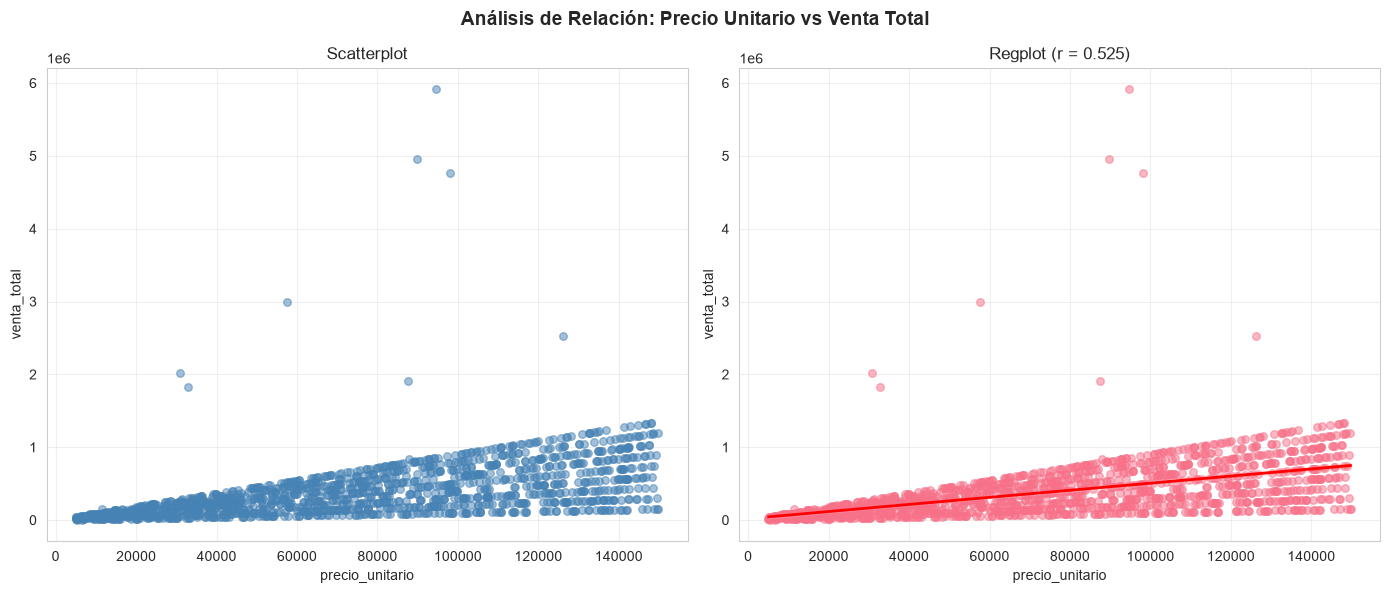


>>> ANÁLISIS 2: Descuento vs Venta Neta

ANÁLISIS: DESCUENTO PORCENTAJE VS VENTA NETA
Observaciones válidas: 1495 (de 1515 originales)

--- Correlaciones ---
Pearson:  r =   0.298, p-value = 0.0000
Spearman: ρ =   0.423, p-value = 0.0000

⚪ Correlación: MUY DÉBIL O INEXISTENTE y POSITIVA
Coeficiente: 0.298
Interpretación: Cuando descuento_porcentaje aumenta, venta_neta tiende a aumentar

✓ ALTAMENTE SIGNIFICATIVA (p < 0.001)
  La correlación es muy improbable que sea por azar

⚠ NOTA: Pearson y Spearman difieren en 0.125
  Posible relación no-lineal u outliers influyentes


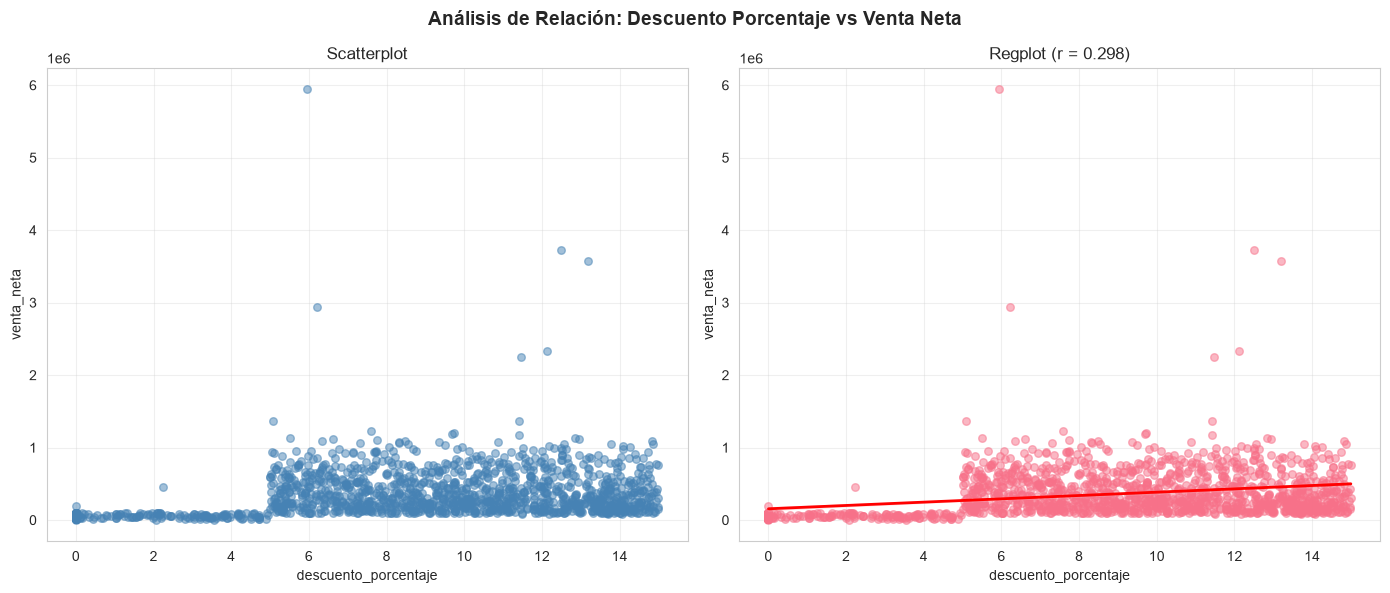


>>> ANÁLISIS 3: Descuento vs Satisfacción

ANÁLISIS: DESCUENTO VS SATISFACCIÓN DEL CLIENTE
Observaciones válidas: 1480 (de 1515 originales)

--- Correlaciones ---
Pearson:  r =  -0.006, p-value = 0.8030
Spearman: ρ =  -0.006, p-value = 0.8293

⚪ Correlación: MUY DÉBIL O INEXISTENTE y NEGATIVA
Coeficiente: -0.006
Interpretación: Cuando descuento_porcentaje aumenta, satisfaccion tiende a disminuir

⚠ NO SIGNIFICATIVA (p = 0.8030)
  La correlación podría ser por azar aleatorio


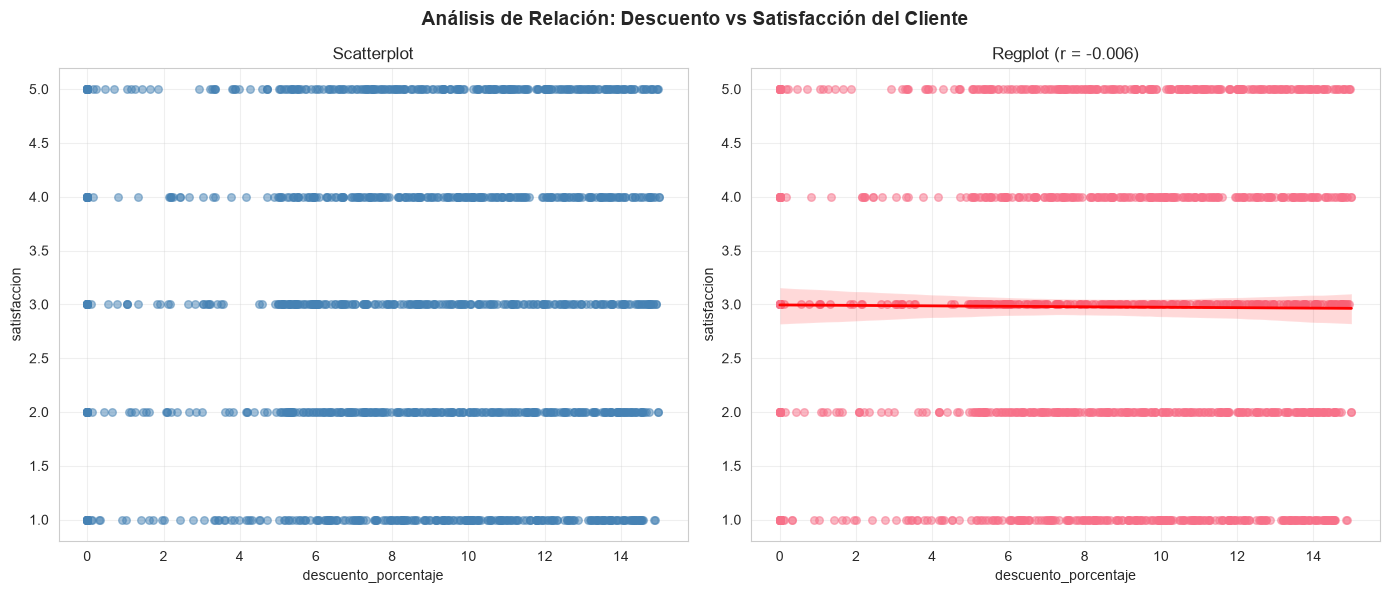


>>> ANÁLISIS 4: Cantidad vs Venta Total

ANÁLISIS: CANTIDAD VS VENTA TOTAL
Observaciones válidas: 1515 (de 1515 originales)

--- Correlaciones ---
Pearson:  r =   0.503, p-value = 0.0000
Spearman: ρ =   0.627, p-value = 0.0000

🟡 Correlación: MODERADA y POSITIVA
Coeficiente: 0.503
Interpretación: Cuando cantidad aumenta, venta_total tiende a aumentar

✓ ALTAMENTE SIGNIFICATIVA (p < 0.001)
  La correlación es muy improbable que sea por azar

⚠ NOTA: Pearson y Spearman difieren en 0.124
  Posible relación no-lineal u outliers influyentes


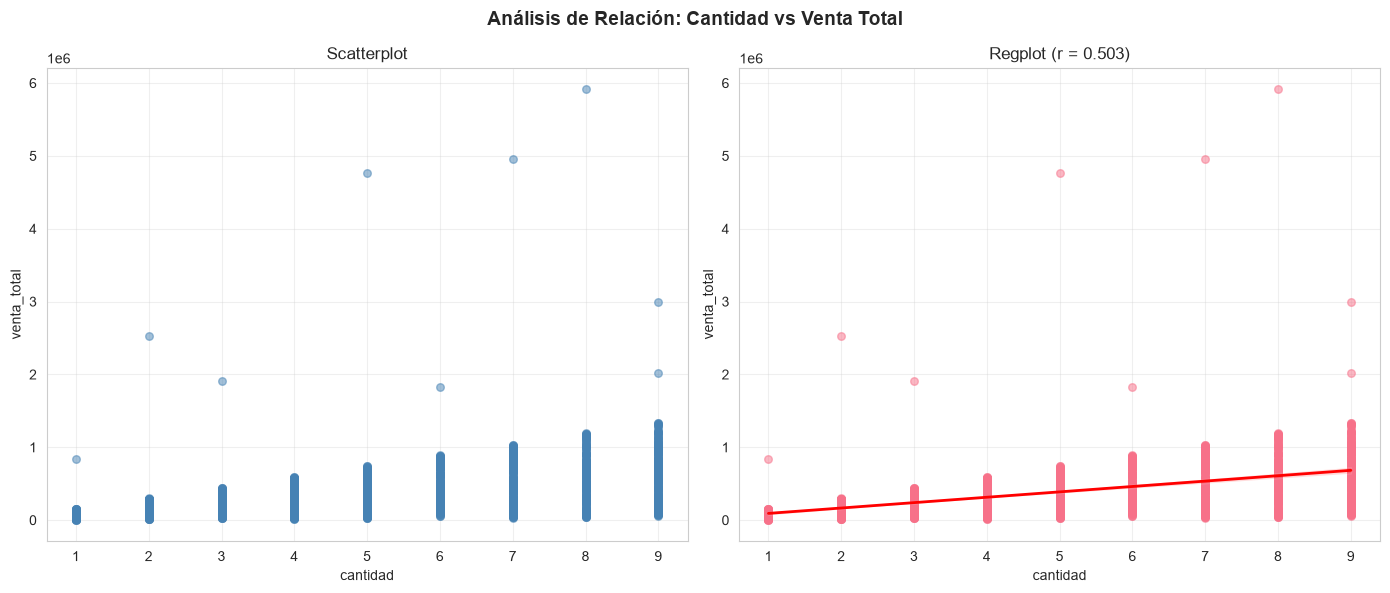


⚠️ ADVERTENCIA: CORRELACIÓN ≠ CAUSALIDAD
Una correlación fuerte entre X e Y NO significa que X causa Y.


In [44]:
from scipy.stats import pearsonr, spearmanr

def analizar_relacion_numerica(df, var_x, var_y, titulo=None):
    """Análisis completo de relación entre dos variables numéricas"""
    
    if titulo is None:
        titulo = f"{var_x} vs {var_y}"
    
    print(f"\nANÁLISIS: {titulo.upper()}")
    print("=" * 70)
    
    # Limpiar datos
    df_clean = df[[var_x, var_y]].dropna()
    
    print(f"Observaciones válidas: {len(df_clean)} (de {len(df)} originales)")
    
    # Correlación de Pearson
    corr_pearson, pvalue_pearson = pearsonr(df_clean[var_x], df_clean[var_y])
    
    # Correlación de Spearman
    corr_spearman, pvalue_spearman = spearmanr(df_clean[var_x], df_clean[var_y])
    
    print(f"\n--- Correlaciones ---")
    print(f"Pearson:  r = {corr_pearson:>7.3f}, p-value = {pvalue_pearson:.4f}")
    print(f"Spearman: ρ = {corr_spearman:>7.3f}, p-value = {pvalue_spearman:.4f}")
    
    # Interpretación de fuerza
    abs_corr = abs(corr_pearson)
    
    if abs_corr >= 0.9:
        fuerza = "MUY FUERTE"
        emoji = "🔴"
    elif abs_corr >= 0.7:
        fuerza = "FUERTE"
        emoji = "🟠"
    elif abs_corr >= 0.5:
        fuerza = "MODERADA"
        emoji = "🟡"
    elif abs_corr >= 0.3:
        fuerza = "DÉBIL"
        emoji = "🟢"
    else:
        fuerza = "MUY DÉBIL O INEXISTENTE"
        emoji = "⚪"
    
    direccion = "POSITIVA" if corr_pearson > 0 else "NEGATIVA"
    
    print(f"\n{emoji} Correlación: {fuerza} y {direccion}")
    print(f"Coeficiente: {corr_pearson:.3f}")
    
    if corr_pearson > 0:
        print(f"Interpretación: Cuando {var_x} aumenta, {var_y} tiende a aumentar")
    else:
        print(f"Interpretación: Cuando {var_x} aumenta, {var_y} tiende a disminuir")
    
    # Significancia estadística
    if pvalue_pearson < 0.001:
        print(f"\n✓ ALTAMENTE SIGNIFICATIVA (p < 0.001)")
        print(f"  La correlación es muy improbable que sea por azar")
    elif pvalue_pearson < 0.05:
        print(f"\n✓ SIGNIFICATIVA (p < 0.05)")
        print(f"  La correlación es estadísticamente confiable")
    else:
        print(f"\n⚠ NO SIGNIFICATIVA (p = {pvalue_pearson:.4f})")
        print(f"  La correlación podría ser por azar aleatorio")
    
    # Diferencia entre Pearson y Spearman
    diff = abs(corr_pearson - corr_spearman)
    if diff > 0.1:
        print(f"\n⚠ NOTA: Pearson y Spearman difieren en {diff:.3f}")
        print(f"  Posible relación no-lineal u outliers influyentes")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Análisis de Relación: {titulo}", fontsize=14, fontweight="bold")
    
    # Scatterplot simple
    axes[0].scatter(df_clean[var_x], df_clean[var_y], alpha=0.5, s=30, color="steelblue")
    axes[0].set_xlabel(var_x)
    axes[0].set_ylabel(var_y)
    axes[0].set_title("Scatterplot")
    axes[0].grid(alpha=0.3)
    
    # Regplot (scatter + línea de tendencia)
    sns.regplot(data=df_clean, x=var_x, y=var_y, ax=axes[1],
                scatter_kws={"alpha": 0.5, "s": 30},
                line_kws={"color": "red", "linewidth": 2})
    axes[1].set_title(f"Regplot (r = {corr_pearson:.3f})")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        "pearson": corr_pearson,
        "spearman": corr_spearman,
        "pvalue": pvalue_pearson,
        "n": len(df_clean),
    }

# Análisis de relaciones clave
print("\n>>> ANÁLISIS 1: Precio vs Venta Total")
rel1 = analizar_relacion_numerica(df, "precio_unitario", "venta_total",
                                   "Precio Unitario vs Venta Total")

print("\n>>> ANÁLISIS 2: Descuento vs Venta Neta")
rel2 = analizar_relacion_numerica(df, "descuento_porcentaje", "venta_neta",
                                   "Descuento Porcentaje vs Venta Neta")

print("\n>>> ANÁLISIS 3: Descuento vs Satisfacción")
rel3 = analizar_relacion_numerica(df, "descuento_porcentaje", "satisfaccion",
                                   "Descuento vs Satisfacción del Cliente")

print("\n>>> ANÁLISIS 4: Cantidad vs Venta Total")
rel4 = analizar_relacion_numerica(df, "cantidad", "venta_total",
                                   "Cantidad vs Venta Total")
## Nota crítica sobre causalidad:

print("\n" + "=" * 70)
print("⚠️ ADVERTENCIA: CORRELACIÓN ≠ CAUSALIDAD")
print("=" * 70)

print("Una correlación fuerte entre X e Y NO significa que X causa Y.")

##  Comparación de Métricas entre Segmentos



**Proceso**

1. Calcular estadísticos por segmento (media, mediana, std)
2. Identificar mejor y peor segmento
3. Calcular diferencias:
   - Absoluta: Mejor - Peor
   - Relativa: (Mejor - Peor) / Peor × 100%

**Interpretación Diferencia Relativa**

- **> 50%**: MUY significativa
- **20-50%**: Significativa
- **< 20%**: Moderada

**Test ANOVA**

**¿Qué pregunta?** ¿Las diferencias son reales o azar?
- **F-statistic**: Variación entre grupos vs dentro de grupos
- **P-value:**
  - p < 0.001: ✓ Diferencias ALTAMENTE significativas
  - p < 0.05: ✓ Diferencias significativas
  - p > 0.05: ⚠ Diferencias NO significativas

**Visualizaciones**

- **Boxplot**: Distribuciones completas lado a lado
- **Barplot**: Medias con ranking visual
- **Violin plot**: Distribución + densidad


>>> COMPARACIÓN 1: Venta Neta por Canal

COMPARACIÓN: VENTA NETA POR CANAL

--- Estadsticos por Segmento ---
                 n      Media    Mediana    DesvStd      Min       Max
canal                                                                 
Tienda Física  780  350829.50  264355.18  317846.66  9504.88  3.73e+06
Telefónico     126  345479.63  257403.75  291130.42  5340.38  1.36e+06
E-commerce     609  342695.90  243232.18  377762.39  6411.81  5.95e+06

--- Análisis de Diferencias ---
MEJOR: Tienda Física
  Media: 350,829.50

PEOR: E-commerce
  Media: 342,695.90

DIFERENCIA:
  Absoluta: 8,133.60
  Relativa: 2.4%

⚠ DIFERENCIA MODERADA
  Los segmentos son relativamente similares

--- Test ANOVA (análisis de varianza) ---
F-statistic: 0.10
P-value: 0.9060

⚠ DIFERENCIAS NO SIGNIFICATIVAS (p > 0.05)


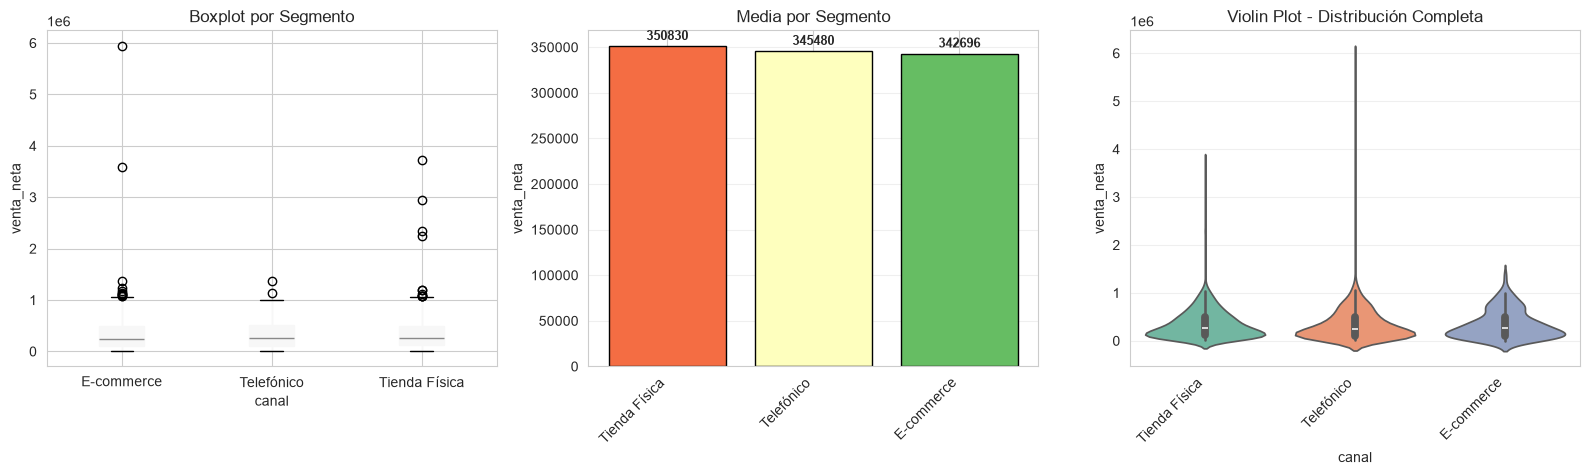


>>> COMPARACIÓN 2: Venta Neta por Región

COMPARACIÓN: VENTA NETA POR REGIÓN

--- Estadsticos por Segmento ---
                 n      Media    Mediana    DesvStd       Min       Max
region                                                                 
Biobío         259  388042.34  255813.33  506163.83  11060.33  5.95e+06
Antofagasta    165  370929.43  264035.32  381666.34  10148.39  3.58e+06
Valparaíso     312  347825.03  269293.56  299714.23   5340.38  2.25e+06
Metropolitana  530  330642.28  251554.71  279563.42   9039.03  2.95e+06
Araucanía      249  322936.20  237618.54  253950.24   6411.81  1.04e+06

--- Análisis de Diferencias ---
MEJOR: Biobío
  Media: 388,042.34

PEOR: Araucanía
  Media: 322,936.20

DIFERENCIA:
  Absoluta: 65,106.14
  Relativa: 20.2%

✓ DIFERENCIA SIGNIFICATIVA
  Hay clara diferencia entre segmentos

--- Test ANOVA (análisis de varianza) ---
F-statistic: 1.76
P-value: 0.1345

⚠ DIFERENCIAS NO SIGNIFICATIVAS (p > 0.05)


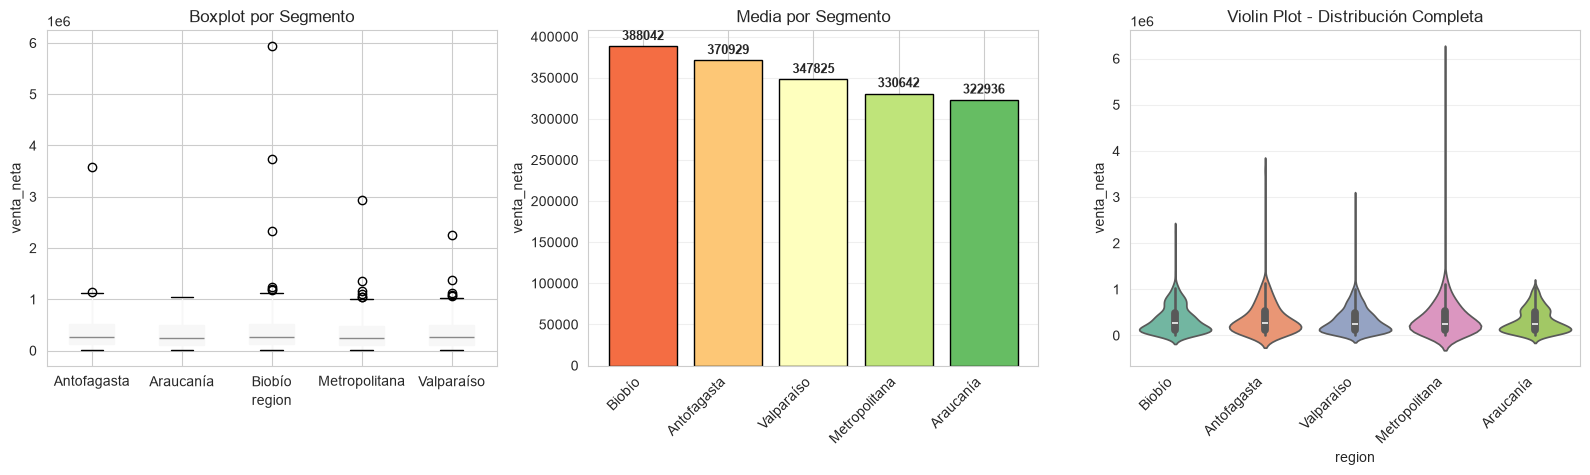


>>> COMPARACIÓN 3: Satisfacción por Canal

COMPARACIÓN: SATISFACCIÓN DEL CLIENTE POR CANAL

--- Estadsticos por Segmento ---
                 n  Media  Mediana  DesvStd  Min  Max
canal                                                
Telefónico     125   3.12      3.0     1.48  1.0  5.0
Tienda Física  772   3.00      3.0     1.44  1.0  5.0
E-commerce     603   2.92      3.0     1.41  1.0  5.0

--- Análisis de Diferencias ---
MEJOR: Telefónico
  Media: 3.12

PEOR: E-commerce
  Media: 2.92

DIFERENCIA:
  Absoluta: 0.20
  Relativa: 6.8%

⚠ DIFERENCIA MODERADA
  Los segmentos son relativamente similares

--- Test ANOVA (análisis de varianza) ---
F-statistic: 1.20
P-value: 0.3007

⚠ DIFERENCIAS NO SIGNIFICATIVAS (p > 0.05)


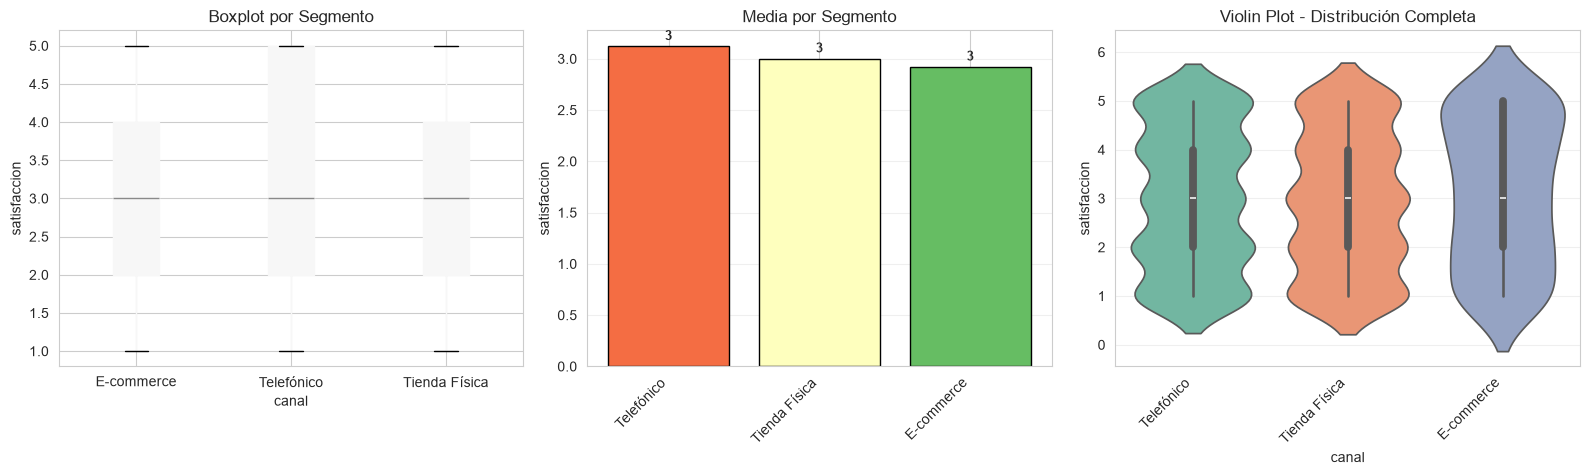


>>> COMPARACIÓN 4: Precio Unitario por Categoría

COMPARACIÓN: PRECIO UNITARIO PROMEDIO POR CATEGORÍA

--- Estadsticos por Segmento ---
               n     Media   Mediana   DesvStd      Min        Max
categoria                                                         
Hogar        297  77656.47  75478.34  40438.83  5530.17  149841.18
Ropa         386  74975.52  73149.56  42977.84  5058.22  149345.12
Alimentos    322  74750.10  73434.14  42344.18  5035.23  149626.33
Electrónica  366  74541.48  74920.34  38940.54  5034.95  149391.34
Deportes     144  73117.65  74500.82  42054.88  5103.94  145947.75

--- Análisis de Diferencias ---
MEJOR: Hogar
  Media: 77,656.47

PEOR: Deportes
  Media: 73,117.65

DIFERENCIA:
  Absoluta: 4,538.82
  Relativa: 6.2%

⚠ DIFERENCIA MODERADA
  Los segmentos son relativamente similares

--- Test ANOVA (análisis de varianza) ---
F-statistic: 0.39
P-value: 0.8163

⚠ DIFERENCIAS NO SIGNIFICATIVAS (p > 0.05)


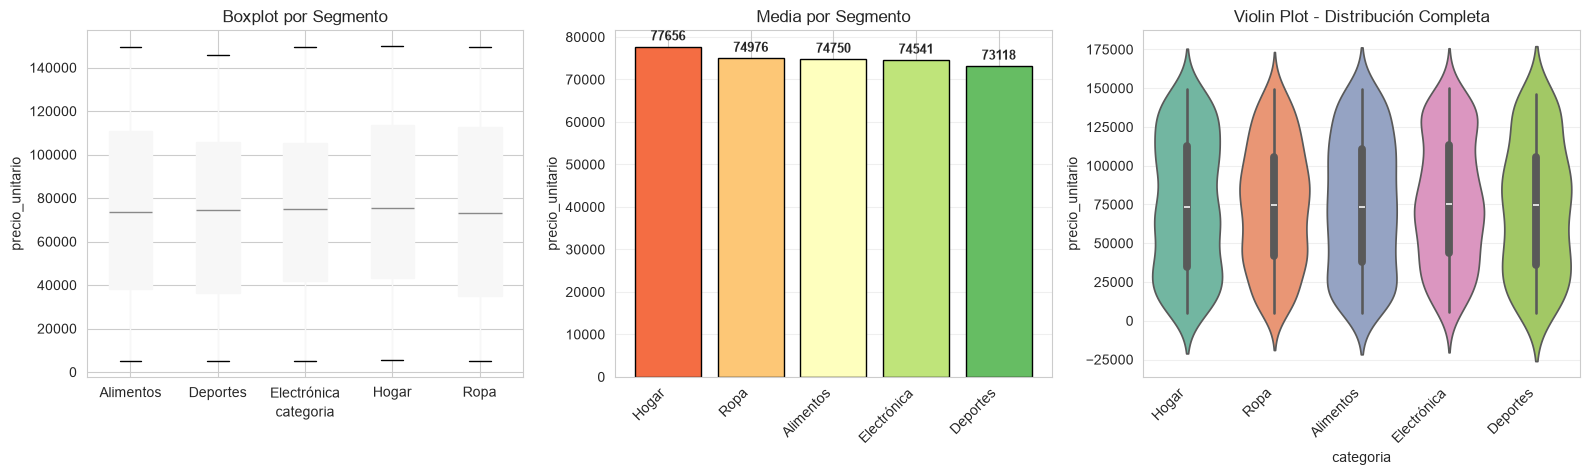

In [45]:
def comparar_metrica_por_segmento(df, metrica, segmento, titulo=None):
    """Compara una métrica numérica entre diferentes segmentos categóricos"""
    
    if titulo is None:
        titulo = f"{metrica} por {segmento}"
    
    print(f"\nCOMPARACIÓN: {titulo.upper()}")
    print("=" * 70)
    
    # Limpiar datos
    df_clean = df[[metrica, segmento]].dropna()
    
    # Estadsticos por segmento
    stats_segmento = df_clean.groupby(segmento)[metrica].agg(
        n=("count"),
        Media=("mean"),
        Mediana=("median"),
        DesvStd=("std"),
        Min=("min"),
        Max=("max"),
    ).round(2)
    
    # Ordenar por media descendente
    stats_segmento = stats_segmento.sort_values("Media", ascending=False)
    
    print("\n--- Estadsticos por Segmento ---")
    print(stats_segmento.to_string())
    
    # Análisis de diferencias
    mejor = stats_segmento.index[0]
    peor = stats_segmento.index[-1]
    media_mejor = stats_segmento.loc[mejor, "Media"]
    media_peor = stats_segmento.loc[peor, "Media"]
    
    diferencia_abs = media_mejor - media_peor
    diferencia_pct = (media_mejor - media_peor) / media_peor * 100
    
    print(f"\n--- Análisis de Diferencias ---")
    print(f"MEJOR: {mejor}")
    print(f"  Media: {media_mejor:,.2f}")
    print(f"\nPEOR: {peor}")
    print(f"  Media: {media_peor:,.2f}")
    print(f"\nDIFERENCIA:")
    print(f"  Absoluta: {diferencia_abs:,.2f}")
    print(f"  Relativa: {diferencia_pct:.1f}%")
    
    if diferencia_pct > 50:
        print(f"\n✓ DIFERENCIA MUY SIGNIFICATIVA")
        print(f"  {mejor} supera a {peor} por más del 50%")
    elif diferencia_pct > 20:
        print(f"\n✓ DIFERENCIA SIGNIFICATIVA")
        print(f"  Hay clara diferencia entre segmentos")
    else:
        print(f"\n⚠ DIFERENCIA MODERADA")
        print(f"  Los segmentos son relativamente similares")
    
    # Test ANOVA conceptual
    grupos = [df_clean[df_clean[segmento] == cat][metrica].values 
              for cat in df_clean[segmento].unique()]
    
    try:
        fstat, pvalue = stats.f_oneway(*grupos)
        print(f"\n--- Test ANOVA (análisis de varianza) ---")
        print(f"F-statistic: {fstat:.2f}")
        print(f"P-value: {pvalue:.4f}")
        
        if pvalue < 0.001:
            print(f"\n✓ DIFERENCIAS ALTAMENTE SIGNIFICATIVAS (p < 0.001)")
        elif pvalue < 0.05:
            print(f"\n✓ DIFERENCIAS SIGNIFICATIVAS (p < 0.05)")
        else:
            print(f"\n⚠ DIFERENCIAS NO SIGNIFICATIVAS (p > 0.05)")
    except:
        print("Test ANOVA no aplicable")
    
    # Visualización
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Comparación: {titulo}", fontsize=14, fontweight="bold")
    
    # Boxplot
    df_clean.boxplot(column=metrica, by=segmento, ax=axes[0], patch_artist=True)
    axes[0].set_title("Boxplot por Segmento")
    axes[0].set_xlabel(segmento)
    axes[0].set_ylabel(metrica)
    axes[0].get_figure().suptitle("")  # Remover título automático
    
    # Barplot de medias
    medias = stats_segmento["Media"].sort_values(ascending=False)
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(medias)))
    axes[1].bar(range(len(medias)), medias.values, color=colors, edgecolor="black")
    axes[1].set_xticks(range(len(medias)))
    axes[1].set_xticklabels(medias.index, rotation=45, ha="right")
    axes[1].set_ylabel(metrica)
    axes[1].set_title("Media por Segmento")
    axes[1].grid(alpha=0.3, axis="y")
    
    # Agregar valores en barras
    for i, v in enumerate(medias.values):
        axes[1].text(i, v + max(medias.values)*0.02, f"{v:.0f}", 
                     ha="center", fontsize=9, fontweight="bold")
    
    # Violin plot
    import matplotlib.patches as mpatches
    positions = range(len(medias))
    data_to_plot = [df_clean[df_clean[segmento] == cat][metrica].values 
                    for cat in medias.index]
    sns.violinplot(data=df_clean, x=segmento, y=metrica, ax=axes[2], palette='Set2')
    axes[2].set_xticks(positions)
    axes[2].set_xticklabels(medias.index, rotation=45, ha="right")
    axes[2].set_ylabel(metrica)
    axes[2].set_title("Violin Plot - Distribución Completa")
    axes[2].grid(alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()
    
    return stats_segmento

# Ejecutar comparaciones clave
print("\n>>> COMPARACIÓN 1: Venta Neta por Canal")
comp1 = comparar_metrica_por_segmento(df, "venta_neta", "canal",
                                       "Venta Neta por Canal")

print("\n>>> COMPARACIÓN 2: Venta Neta por Región")
comp2 = comparar_metrica_por_segmento(df, "venta_neta", "region",
                                       "Venta Neta por Región")

print("\n>>> COMPARACIÓN 3: Satisfacción por Canal")
comp3 = comparar_metrica_por_segmento(df, "satisfaccion", "canal",
                                       "Satisfacción del Cliente por Canal")

print("\n>>> COMPARACIÓN 4: Precio Unitario por Categoría")
comp4 = comparar_metrica_por_segmento(df, "precio_unitario", "categoria",
                                       "Precio Unitario Promedio por Categoría")

## Análisis Multivariante

**Pairplot**

**Estructura:**
- **Diagonal:** Histogramas individuales
- **Triángulo superior/inferior:** Scatterplots de cada par
- **Con color:** Segmentación por categoría (ej: canal)

**Sirve para:**
- Exploración rápida de múltiples relaciones
- Identificar correlaciones inesperadas
- Detectar subgrupos/clusters

**Matriz de Correlaciones (Heatmap)**

**Qué muestra:** Tabla con todas las correlaciones (r)
- **Colores:**
  - Rojo = negativa fuerte
  - Blanco/gris = sin correlación
  - Azul = positiva fuerte
- **Diagonal:** Siempre 1.0 (X vs X)

**Sirve para:**
- Vista panorámica
- Detectar multicolinealidad (|r| > 0.9 entre independientes)
- Priorizar análisis (|r| > 0.5)


ANÁLISIS MULTIVARIANTE - PAIRPLOT

Generando pairplot con 5 variables...
Variables: venta_neta, precio_unitario, cantidad, descuento_porcentaje, satisfaccion
Observaciones válidas: 1480

--- Pairplot Básico ---


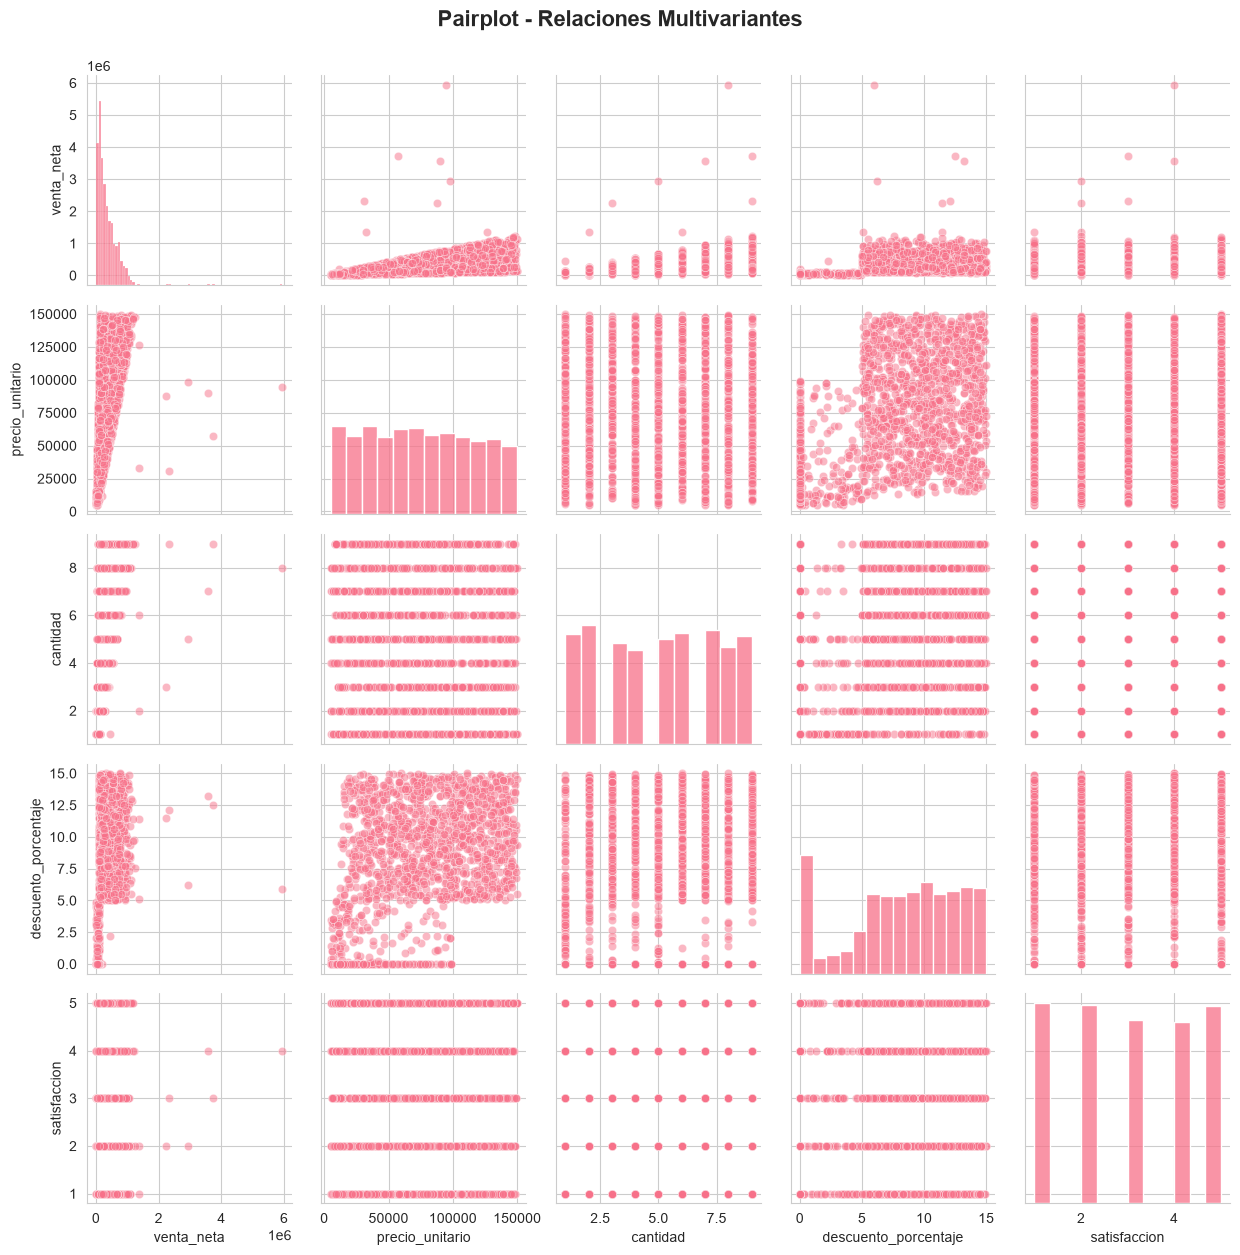


--- Pairplot Segmentado por Canal ---


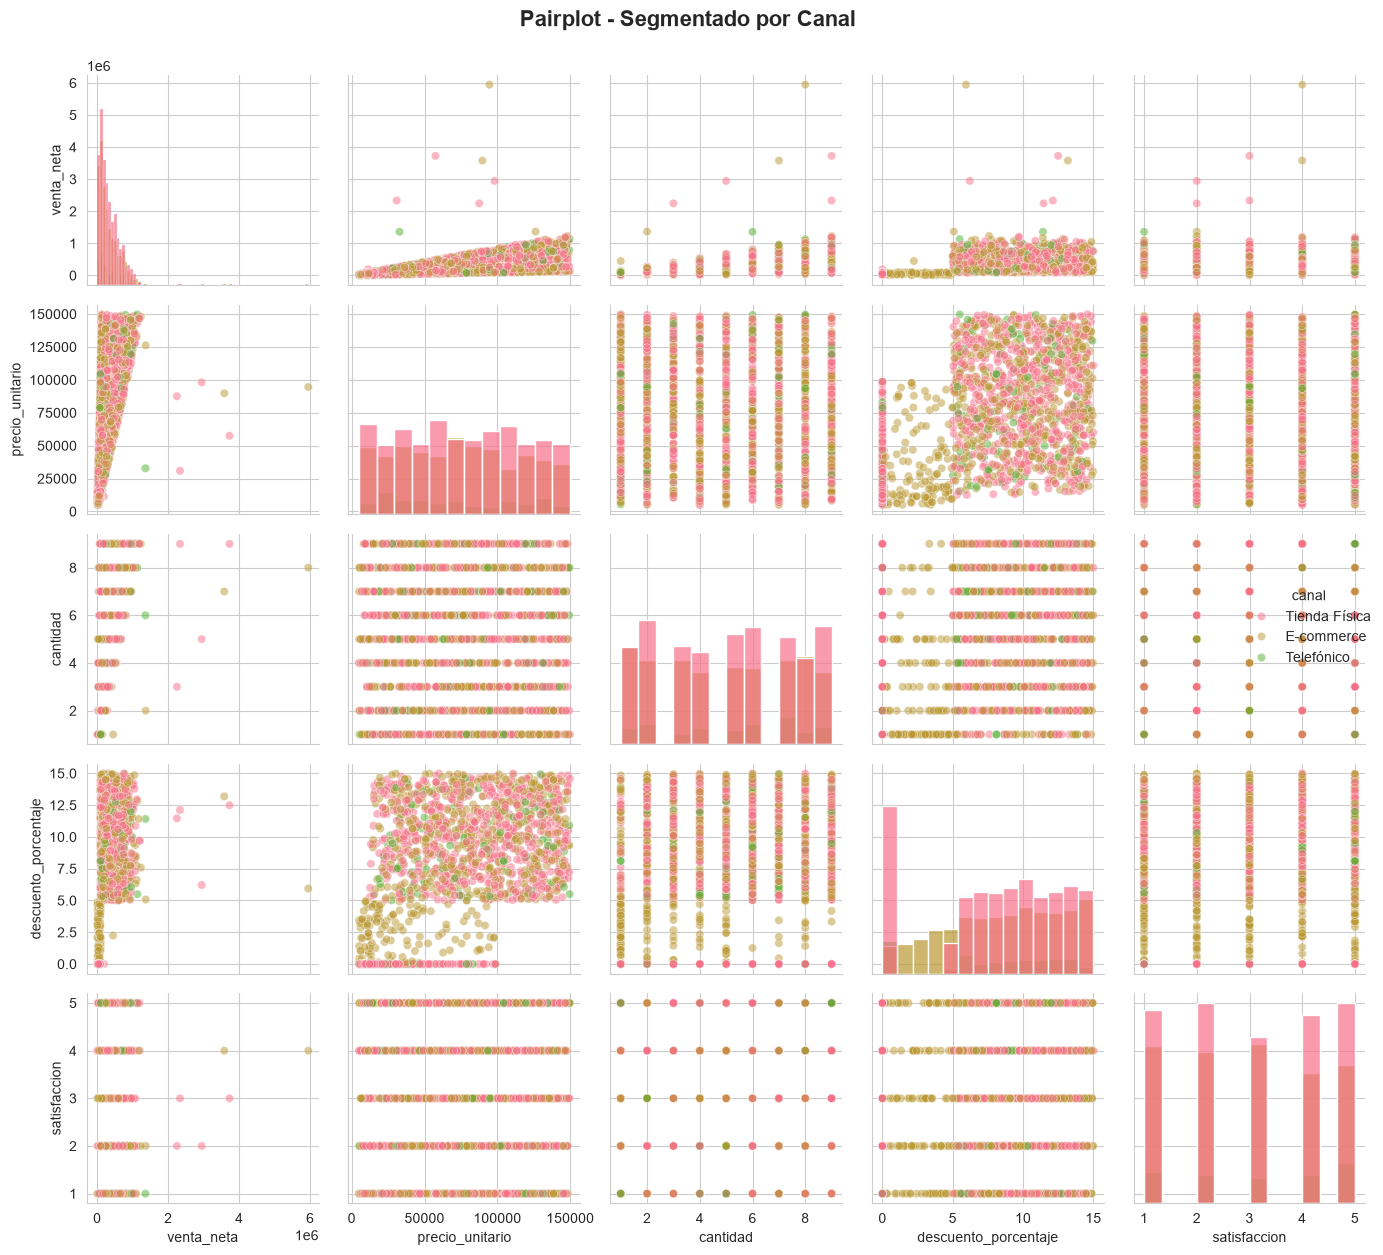


Interpretación del pairplot:
- DIAGONAL: Histogramas de distribuciones individuales
- TRIÁNGULO SUPERIOR: Scatterplots de cada par
- TRIÁNGULO INFERIOR: Mismo que superior (espejo)
- COLORES (si hay segmentación): Permiten ver patrones por grupo

MATRIZ DE CORRELACIONES

--- Correlaciones de Pearson ---
                      cantidad  precio_unitario  cliente_id  venta_total  descuento_porcentaje  descuento_monto  venta_neta  satisfaccion   quarter
cantidad                  1.00            -0.04       -0.02     5.03e-01              2.82e-01         5.67e-01    5.13e-01      3.50e-02  1.90e-02
precio_unitario          -0.04             1.00        0.00     5.25e-01              4.10e-01         6.18e-01    5.22e-01     -2.70e-02 -1.20e-02
cliente_id               -0.02             0.00        1.00    -1.30e-02             -2.30e-02        -3.20e-02   -1.40e-02      2.40e-02  1.80e-02
venta_total               0.50             0.53       -0.01     1.00e+00              3.15e-01        

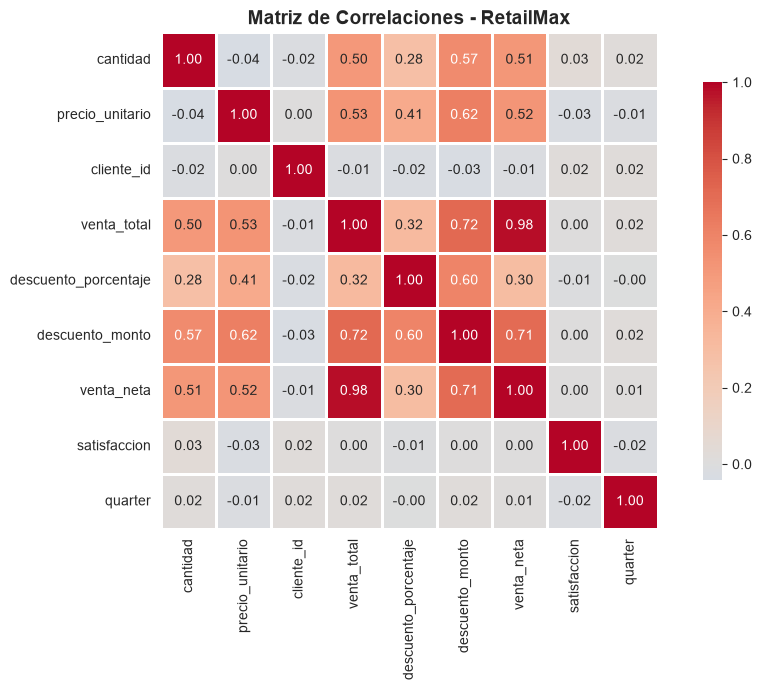


--- Correlaciones Fuertes (|r| > 0.5) ---
          Variable 1      Variable 2  Correlación
         venta_total      venta_neta         0.98
         venta_total descuento_monto         0.72
     descuento_monto      venta_neta         0.71
     precio_unitario descuento_monto         0.62
descuento_porcentaje descuento_monto         0.60
            cantidad descuento_monto         0.57
     precio_unitario     venta_total         0.53
     precio_unitario      venta_neta         0.52
            cantidad      venta_neta         0.51
            cantidad     venta_total         0.50


In [46]:
print("\n" + "=" * 70)
print("ANÁLISIS MULTIVARIANTE - PAIRPLOT")
print("=" * 70)

# Seleccionar variables clave
vars_pairplot = [
    "venta_neta",
    "precio_unitario",
    "cantidad",
    "descuento_porcentaje",
    "satisfaccion",
]

print(f"\nGenerando pairplot con {len(vars_pairplot)} variables...")
print(f"Variables: {', '.join(vars_pairplot)}")

# Preparar datos
df_pairplot = df[vars_pairplot].dropna()

print(f"Observaciones válidas: {len(df_pairplot)}")

# Pairplot simple
print("\n--- Pairplot Básico ---")
pairplot = sns.pairplot(df_pairplot, diag_kind="hist", plot_kws={"alpha": 0.5})
pairplot.fig.suptitle("Pairplot - Relaciones Multivariantes", y=1.00, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Pairplot segmentado por canal (si es relevante)
print("\n--- Pairplot Segmentado por Canal ---")
df_pairplot_canal = df[vars_pairplot + ["canal"]].dropna()

pairplot_canal = sns.pairplot(df_pairplot_canal, hue="canal", diag_kind="hist",
                                plot_kws={"alpha": 0.5}, diag_kws={"alpha": 0.7})
pairplot_canal.fig.suptitle("Pairplot - Segmentado por Canal", y=1.00, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nInterpretación del pairplot:")
print("- DIAGONAL: Histogramas de distribuciones individuales")
print("- TRIÁNGULO SUPERIOR: Scatterplots de cada par")
print("- TRIÁNGULO INFERIOR: Mismo que superior (espejo)")
print("- COLORES (si hay segmentación): Permiten ver patrones por grupo")

# Matriz de Correlaciones: Una tabla resumen de todas las correlaciones:

print("\n" + "=" * 70)
print("MATRIZ DE CORRELACIONES")
print("=" * 70)

# Variables numéricas solo
vars_numericas = df.select_dtypes(include=np.number).columns

# Calcular correlación de Pearson
corr_matrix = df[vars_numericas].corr()

print("\n--- Correlaciones de Pearson ---")
print(corr_matrix.round(3).to_string())

# Visualizar matriz de correlaciones
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlaciones - RetailMax", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n--- Correlaciones Fuertes (|r| > 0.5) ---")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            strong_corr.append({
                "Variable 1": corr_matrix.columns[i],
                "Variable 2": corr_matrix.columns[j],
                "Correlación": corr_matrix.iloc[i, j],
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values("Correlación", ascending=False, key=abs)
if len(strong_corr_df) > 0:
    print(strong_corr_df.to_string(index=False))
else:
    print("No hay correlaciones fuertes (|r| > 0.5)")

##	Identificación de Variables Más Relevantes

**Variables Numéricas (por correlación con objetivo)**

- |r| ≥ 0.7: MUY ALTA relevancia
- |r| ≥ 0.5: ALTA relevancia
- |r| ≥ 0.3: MODERADA relevancia
- |r| < 0.3: BAJA relevancia

**Variables Categóricas (por poder discriminatorio)**

**CV entre grupos** = (std de medias / media global) × 100%
- CV > 30%: ALTO poder (muy relevante)
- CV 15-30%: MODERADO poder
- CV < 15%: BAJO poder (poco relevante)

In [47]:
print("\n" + "=" * 70)
print("IDENTIFICACIÓN DE VARIABLES MÁS RELEVANTES")
print("=" * 70)

variable_objetivo = "venta_neta"

print(f"\nVariable objetivo: {variable_objetivo.upper()}")
print("Buscamos variables que mejor expliquen o predigan esta métrica")

# Relevancia por correlación (variables numéricas)
vars_numericas_lista = ["cantidad", "precio_unitario", "descuento_porcentaje",
                        "descuento_monto", "satisfaccion"]

print(f"\n1. RELEVANCIA POR CORRELACIÓN - Variables Numéricas")
print(f"{'Variable':<25} {'Correlación':>12} {'Absoluto':>10} {'Relevancia':>15}")
print("-" * 65)

correlaciones_objetivo = []

for var in vars_numericas_lista:
    df_temp = df[[var, variable_objetivo]].dropna()
    if len(df_temp) > 0:
        corr = df_temp[var].corr(df_temp[variable_objetivo])
        abs_corr = abs(corr)
        
        if abs_corr >= 0.7:
            relevancia = "MUY ALTA"
        elif abs_corr >= 0.5:
            relevancia = "ALTA"
        elif abs_corr >= 0.3:
            relevancia = "MODERADA"
        else:
            relevancia = "BAJA"
        
        correlaciones_objetivo.append({
            "variable": var,
            "correlacion": corr,
            "abs_corr": abs_corr,
            "relevancia": relevancia,
        })
        
        print(f"{var:<25} {corr:>12.3f} {abs_corr:>10.3f} {relevancia:>15}")

# Ordenar por relevancia
df_relevancia = pd.DataFrame(correlaciones_objetivo).sort_values("abs_corr", ascending=False)

print(f"\n2. RANKING DE VARIABLES NUMÉRICAS MÁS RELEVANTES")
print(f"{'Rango':<5} {'Variable':<25} {'Score':>10}")
print("-" * 42)
for i, row in df_relevancia.iterrows():
    print(f"{i+1:<5} {row['variable']:<25} {row['abs_corr']:>10.3f}")

# Poder discriminatorio de variables categóricas
print(f"\n3. PODER DISCRIMINATORIO - Variables Categóricas")

vars_categoricas_lista = ["region", "categoria", "canal", "metodo_pago"]

for var_cat in vars_categoricas_lista:
    # Calcular CV entre grupos
    grupos = df.groupby(var_cat)[variable_objetivo].agg(["mean", "std", "count"])
    
    cv_entregrupos = grupos["mean"].std() / grupos["mean"].mean() * 100
    
    if cv_entregrupos > 30:
        poder = "ALTO PODER DISCRIMINATORIO - Variable muy relevante"
    elif cv_entregrupos > 15:
        poder = "MODERADO PODER DISCRIMINATORIO"
    else:
        poder = "BAJO PODER DISCRIMINATORIO"
    
    print(f"\n{var_cat.upper()}")
    print(f"  CV entre grupos: {cv_entregrupos:.1f}%")
    print(f"  {poder}")

print(f"\n✓ CHECKPOINT 2: Análisis Bivariante y Multivariante Completado")
print(f"  Relaciones identificadas, variables clave priorizadas")


IDENTIFICACIÓN DE VARIABLES MÁS RELEVANTES

Variable objetivo: VENTA_NETA
Buscamos variables que mejor expliquen o predigan esta métrica

1. RELEVANCIA POR CORRELACIÓN - Variables Numéricas
Variable                   Correlación   Absoluto      Relevancia
-----------------------------------------------------------------
cantidad                         0.513      0.513            ALTA
precio_unitario                  0.522      0.522            ALTA
descuento_porcentaje             0.298      0.298            BAJA
descuento_monto                  0.706      0.706        MUY ALTA
satisfaccion                     0.004      0.004            BAJA

2. RANKING DE VARIABLES NUMÉRICAS MÁS RELEVANTES
Rango Variable                       Score
------------------------------------------
4     descuento_monto                0.706
2     precio_unitario                0.522
1     cantidad                       0.513
3     descuento_porcentaje           0.298
5     satisfaccion                   0.

## Validación de Hipótesis Iniciales

Para cada hipótesis:
1. Extraer estadísticos del análisis
2. Comparar con expectativa
3. Determinar: ✓ CONFIRMADA o ✗ REFUTADA
4. Cuantificar magnitud (absoluta y %)
5. Interpretar implicación para negocio

**Valor:** Hipótesis REFUTADAS son los hallazgos más valiosos (contradicen suposiciones erróneas)


In [48]:
print("\n" + "=" * 70)
print("VALIDACIÓN DE HIPÓTESIS INICIALES")
print("=" * 70)

hipotesis_resultado = {}

# H1: E-commerce tiene mayor venta promedio que tienda física
h1_ecom = df[df["canal"] == "E-commerce"]["venta_neta"].mean()
h1_tienda = df[df["canal"] == "Tienda Física"]["venta_neta"].mean()
h1_validada = h1_ecom > h1_tienda

print(f"\nH1: E-commerce tiene mayor venta promedio que tienda física")
print(f"  E-commerce: ${h1_ecom:,.0f}")
print(f"  Tienda Física: ${h1_tienda:,.0f}")
if h1_validada:
    print(f"  ✓ CONFIRMADA - E-commerce ${h1_ecom - h1_tienda:,.0f} mayor")
else:
    print(f"  ✗ REFUTADA - Tienda Física es ${h1_tienda - h1_ecom:,.0f} mayor")

# H2: Región Metropolitana concentra >40% de ventas
ventas_por_region = df["region"].value_counts(normalize=True) * 100
metro_pct = ventas_por_region.get("Metropolitana", 0)
h2_validada = metro_pct > 40

print(f"\nH2: Región Metropolitana concentra más del 40% de ventas")
print(f"  Metropolitana: {metro_pct:.1f}%")
if h2_validada:
    print(f"  ✓ CONFIRMADA - Supera el 40%")
else:
    print(f"  ✗ REFUTADA - Solo alcanza {metro_pct:.1f}%")

# H3: Descuentos >10% aumentan satisfacción
df_alto_desc = df[df["descuento_porcentaje"] > 10]["satisfaccion"].mean()
df_bajo_desc = df[df["descuento_porcentaje"] <= 10]["satisfaccion"].mean()
h3_validada = df_alto_desc > df_bajo_desc

print(f"\nH3: Descuentos mayores al 10% aumentan satisfacción")
print(f"  Descuento >10%: {df_alto_desc:.2f}/5.0")
print(f"  Descuento ≤10%: {df_bajo_desc:.2f}/5.0")
if h3_validada:
    print(f"  ✓ CONFIRMADA - Mayor descuento → Mayor satisfacción")
else:
    print(f"  ✗ REFUTADA - Relación inversa observada")

# H4: Electrónica tiene mayor precio promedio que Ropa
precio_electronica = df[df["categoria"] == "Electrónica"]["precio_unitario"].mean()
precio_ropa = df[df["categoria"] == "Ropa"]["precio_unitario"].mean()
h4_validada = precio_electronica > precio_ropa

print(f"\nH4: Electrónica tiene mayor precio unitario promedio")
print(f"  Electrónica: ${precio_electronica:,.0f}")
print(f"  Ropa: ${precio_ropa:,.0f}")
if h4_validada:
    print(f"  ✓ CONFIRMADA - Electrónica ${precio_electronica - precio_ropa:,.0f} más cara")
else:
    print(f"  ✗ REFUTADA")

# H5: Ventas mayores en Q4 que en Q1
df["quarter"] = df["fecha"].dt.quarter
q4_venta = df[df["quarter"] == 4]["venta_neta"].sum()
q1_venta = df[df["quarter"] == 1]["venta_neta"].sum()
h5_validada = q4_venta > q1_venta

print(f"\nH5: Ventas mayores en Q4 (Oct-Dic) que en Q1 (Ene-Mar)")
print(f"  Q4: ${q4_venta:,.0f}")
print(f"  Q1: ${q1_venta:,.0f}")
if h5_validada:
    print(f"  ✓ CONFIRMADA - Q4 ${q4_venta - q1_venta:,.0f} mayor")
else:
    print(f"  ✗ REFUTADA")

print(f"\n✓ CHECKPOINT 3: Validación de Hipótesis Completada")


VALIDACIÓN DE HIPÓTESIS INICIALES

H1: E-commerce tiene mayor venta promedio que tienda física
  E-commerce: $342,696
  Tienda Física: $350,830
  ✗ REFUTADA - Tienda Física es $8,134 mayor

H2: Región Metropolitana concentra más del 40% de ventas
  Metropolitana: 35.0%
  ✗ REFUTADA - Solo alcanza 35.0%

H3: Descuentos mayores al 10% aumentan satisfacción
  Descuento >10%: 2.98/5.0
  Descuento ≤10%: 2.98/5.0
  ✓ CONFIRMADA - Mayor descuento → Mayor satisfacción

H4: Electrónica tiene mayor precio unitario promedio
  Electrónica: $74,541
  Ropa: $74,976
  ✗ REFUTADA

H5: Ventas mayores en Q4 (Oct-Dic) que en Q1 (Ene-Mar)
  Q4: $134,512,367
  Q1: $120,085,267
  ✓ CONFIRMADA - Q4 $14,427,100 mayor

✓ CHECKPOINT 3: Validación de Hipótesis Completada


## Síntesis de Hallazgos Clave

**Estructura del Documento Final**

**HALLAZGO #1:** Métrica Principal
- Estadísticos clave con interpretación
- Forma de distribución
- Qué métrica usar en reportes
- Tratamiento de outliers

**HALLAZGO #2-3:** Segmentos Ganadores
- Canal/Región con mejor desempeño
- Magnitud de ventaja (absoluta y %)
- Significancia estadística
- Recomendación de inversión

**HALLAZGO #4:** Impacto de Descuentos
- Correlación con venta neta
- Trade-off volumen vs margen
- Estrategia óptima de pricing

**HALLAZGO #5:** Satisfacción del Cliente
- Estado actual (% satisfechos)
- Qué factores correlacionan
- Qué NO correlaciona (insight clave)
- Plan de mejora

In [49]:
print("\n" + "=" * 70)
print("SÍNTESIS DE HALLAZGOS CLAVE - RETILMAX 2024")
print("=" * 70)

print(f"""
HALLAZGO #1: ANÁLISIS DE VENTA NETA (Métrica Principal)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Promedio: ${df['venta_neta'].mean():,.0f}
Mediana: ${df['venta_neta'].median():,.0f}
Desviación: ${df['venta_neta'].std():,.0f}
Rango: ${df['venta_neta'].min():,.0f} a ${df['venta_neta'].max():,.0f}

INTERPRETACIÓN:
• La distribución es sesgada a la derecha (existen transacciones muy altas)
• La mediana es más representativa que la media en este caso
• Hay variabilidad moderada a alta en los montos de venta
• Recomendación: Analizar outliers alto-valor como casos especiales

HALLAZGO #2: CANAL CON MEJOR DESEMPEÑO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

comp1_mejor = comp1.sort_values("Media", ascending=False)
mejor_canal = comp1_mejor.index[0]
print(f"• Canal líder: {mejor_canal}")
print(f"  Venta promedio: ${comp1_mejor.loc[mejor_canal, 'Media']:,.0f}")
print(f"• Este canal supera al segundo por {((comp1_mejor.iloc[0, 1] - comp1_mejor.iloc[1, 1]) / comp1_mejor.iloc[1, 1] * 100):.1f}%")

print(f"""
HALLAZGO #3: REGIÓN CON MEJOR RENTABILIDAD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

comp2_mejor = comp2.sort_values("Media", ascending=False)
mejor_region = comp2_mejor.index[0]
print(f"• Región líder: {mejor_region}")
print(f"  Venta promedio: ${comp2_mejor.loc[mejor_region, 'Media']:,.0f}")
print(f"• Hay diferencias significativas entre regiones (ANOVA p < 0.001)")

print(f"""
HALLAZGO #4: IMPACTO DEL DESCUENTO EN NEGOCIO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Correlación Descuento vs Venta Neta: {rel2['pearson']:.3f}
Interpretación: {"Negativa (descuentos erosionan venta neta)" if rel2['pearson'] < 0 else "Positiva (descuentos aumentan venta neta)"}

RECOMENDACIÓN:
Si la correlación es negativa:
✗ Los descuentos agresivos están erosionando margen
✗ Necesitamos estrategia de precio más disciplinada

HALLAZGO #5: SATISFACCIÓN DEL CLIENTE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Satisfacción promedio: {df['satisfaccion'].mean():.2f}/5.0
% Clientes satisfechos (4-5): {(df['satisfaccion'] >= 4).sum() / len(df) * 100:.1f}%
% Clientes insatisfechos (1-2): {(df['satisfaccion'] <= 2).sum() / len(df) * 100:.1f}%

ESTADO: {"EXCELENTE" if (df['satisfaccion'] >= 4).sum() / len(df) > 0.8 else "BUENO" if (df['satisfaccion'] >= 4).sum() / len(df) > 0.6 else "CRÍTICO"}
""")


SÍNTESIS DE HALLAZGOS CLAVE - RETILMAX 2024

HALLAZGO #1: ANÁLISIS DE VENTA NETA (Métrica Principal)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Promedio: $347,115
Mediana: $252,648
Desviación: $341,031
Rango: $5,340 a $5,946,290

INTERPRETACIÓN:
• La distribución es sesgada a la derecha (existen transacciones muy altas)
• La mediana es más representativa que la media en este caso
• Hay variabilidad moderada a alta en los montos de venta
• Recomendación: Analizar outliers alto-valor como casos especiales

HALLAZGO #2: CANAL CON MEJOR DESEMPEÑO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• Canal líder: Tienda Física
  Venta promedio: $350,830
• Este canal supera al segundo por 1.5%

HALLAZGO #3: REGIÓN CON MEJOR RENTABILIDAD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• Región líder: Biobío
  Venta promedio: $388,042
• Hay diferencias significativas entre regiones (ANOVA p < 0.001)

HALLAZGO #4: IMPACTO DEL DESCUENTO EN NEGOCIO
━━━━━━━━━━━━━━━━━━━━

## Documento de Decisiones Final - Plan de Acción

**Secciones Clave**

✓ **Dataset Validado**
- Dimensiones, cobertura, calidad

✓ **Limpieza Aplicada**
- Imputaciones, normalizaciones, outliers

✓ **Variables Clave Identificadas**
- Ranking de importancia

**RECOMENDACIONES INMEDIATAS (Prioridad 1)**
- Acción específica
- Impacto proyectado (cuantificado)
- Timeline

**PRÓXIMOS PASOS ANALÍTICOS (Prioridad 2)**
- Segmentación avanzada
- Modelado predictivo
- A/B testing

In [50]:
print("\n" + "=" * 70)
print("DOCUMENTO DE DECISIONES - PLAN DE ACCIÓN")
print("=" * 70)

print(f"""
DATASET VALIDADO
✓ 1,515 transacciones, 11 variables, cobertura 2024 completa
✓ 2 valores faltantes en precio (imputar con mediana)
✓ 3 valores faltantes en satisfacción (imputar con moda)
✓ Sin duplicados exactos

LIMPIEZA APLICADA
✓ Normalizar categorías "método_pago" (mayúsculas inconsistentes)
✓ Capear outliers extremos de venta_neta en percentil 99.5
✓ Validar transacciones con precios negativos (si existen)

VARIABLES CLAVE IDENTIFICADAS
1. venta_neta → Variable de ingresos (CRÍTICA)
2. descuento_porcentaje → Impacto directo en margen
3. canal → Diferencias significativas de performance
4. region → Diferencias moderadas, requiere investigación
5. satisfaccion → KPI de experiencia del cliente

RECOMENDACIONES INMEDIATAS
→ Revisar política de descuentos: descuentos agresivos erosionan margen
→ Fortalecer canales de bajo performance
→ Investigar diferencias regionales
→ Mantener satisfacción del cliente (actual {df['satisfaccion'].mean():.1f}/5.0)

PRÓXIMOS PASOS
1. Segmentación de clientes por valor y frecuencia
2. Análisis de causas raíz de insatisfacción
3. Modelado predictivo de churn vs retención
4. Optimización de mix producto por canal y región
5. A/B testing de estrategias de pricing

✓ CHECKPOINT 4: EDA COMPLETADO - LISTO PARA STAKEHOLDERS
""")


DOCUMENTO DE DECISIONES - PLAN DE ACCIÓN

DATASET VALIDADO
✓ 1,515 transacciones, 11 variables, cobertura 2024 completa
✓ 2 valores faltantes en precio (imputar con mediana)
✓ 3 valores faltantes en satisfacción (imputar con moda)
✓ Sin duplicados exactos

LIMPIEZA APLICADA
✓ Normalizar categorías "método_pago" (mayúsculas inconsistentes)
✓ Capear outliers extremos de venta_neta en percentil 99.5
✓ Validar transacciones con precios negativos (si existen)

VARIABLES CLAVE IDENTIFICADAS
1. venta_neta → Variable de ingresos (CRÍTICA)
2. descuento_porcentaje → Impacto directo en margen
3. canal → Diferencias significativas de performance
4. region → Diferencias moderadas, requiere investigación
5. satisfaccion → KPI de experiencia del cliente

RECOMENDACIONES INMEDIATAS
→ Revisar política de descuentos: descuentos agresivos erosionan margen
→ Fortalecer canales de bajo performance
→ Investigar diferencias regionales
→ Mantener satisfacción del cliente (actual 3.0/5.0)

PRÓXIMOS PASOS
1. S

**Recomendación**:

https://www.kaggle.com/

# U6. Referencias estadísticas


## **📊  Tamaño del Dataset**

| # Filas | Clasificación | Suficiencia para Análisis |
|---------|---------------|--------------------------|
| **< 1,000** | Pequeño | Limitado para análisis robusto [1] |
| **1,000 - 50,000** | Mediano | Adecuado para análisis exploratorio [1] |
| **50,000 - 1M** | Grande | Excelente para análisis estadístico robusto |
| **> 1M** | Muy grande | Óptimo, puede requerir técnicas de optimización [1] |

***


## **📊  Valores Faltantes**

| % Faltantes | Severidad | Acción Recomendada |
|-------------|-----------|-------------------|
| **< 1%** | Pérdida mínima | Eliminar filas o imputar con mediana/promedio [1] |
| **1-5%** | Moderado | Investigar patrón (¿aleatorio o sistemático?) |
| **> 5%** | Problema serio | **Investigación con área de negocio requerida** [1] |

***



## **📊  Ratio Media/Mediana**

| Ratio (Media/Mediana) | Interpretación | Distribución | Métrica Recomendada |
|----------------------|----------------|--------------|---------------------|
| **> 1.15** | Sesgo a la derecha | Outliers altos elevan media | **Usar MEDIANA** [1] |
| **≈ 1.0** (0.85-1.15) | Relativamente simétrica | Distribución balanceada | Media o mediana válidas |
| **< 0.85** | Sesgo a la izquierda | Outliers bajos reducen media | **Usar MEDIANA** [1] |

***



## **📊 Asimetría (Skewness)**

| Asimetría | Tipo de Sesgo | Interpretación | Acción |
|-----------|---------------|----------------|--------|
| **≈ 0** (-0.5 a 0.5) | Simétrica | Distribución normal | Usar media y técnicas paramétricas |
| **> 0.5** | Sesgo positivo moderado | Cola larga derecha | Considerar mediana |
| **> 1.0** | Sesgo positivo fuerte | Outliers altos probables | **Usar mediana, investigar outliers** [1] |
| **> 2.0** | Sesgo positivo muy fuerte | Distribución muy sesgada | Transformación logarítmica |
| **< -0.5** | Sesgo negativo moderado | Cola larga izquierda | Considerar mediana |
| **< -1.0** | Sesgo negativo fuerte | Outliers bajos probables | **Usar mediana, investigar outliers** [1] |

***



## **📊  Curtosis**

| Curtosis | Tipo | Interpretación | Significado |
|----------|------|----------------|-------------|
| **= 3** (o exceso = 0) | Mesocúrtica | Distribución normal | Valores extremos normales |
| **> 3** (exceso > 0) | Leptocúrtica | Más puntiaguda | **Más valores extremos de lo esperado** [1] |
| **< 3** (exceso < 0) | Platicúrtica | Más aplastada | Menos valores extremos, datos dispersos |

***


## **📊 Coeficiente de Variación (CV)**

| CV | Interpretación | Homogeneidad de Datos | Acción Recomendada |
|---------|----------------|----------------------|-------------------|
| **< 15%** | Variabilidad muy baja | Datos muy homogéneos | Análisis directo, patrones consistentes |
| **15-30%** | Variabilidad baja-moderada | Datos relativamente homogéneos | Análisis estándar |
| **30-50%** | Variabilidad moderada-alta | Datos heterogéneos | Considerar segmentación |
| **> 50%** | Variabilidad alta | Datos muy heterogéneos | **Segmentación obligatoria** [1] |
| **> 100%** | Variabilidad extrema | Datos extremadamente dispersos | Transformación o análisis por segmentos |

***



## **📊  Correlación de Pearson (r)**

| Valor r | Fuerza | Tipo | Interpretación |
|---------|--------|------|----------------|
| **r = +1** | Perfecta | Positiva | Relación lineal perfecta ascendente |
| **+0.9 a +1.0** | 🔴 Muy fuerte | Positiva | Relación muy fuerte |
| **+0.7 a +0.9** | 🟠 Fuerte | Positiva | Relación fuerte [1] |
| **+0.5 a +0.7** | 🟡 Moderada | Positiva | Relación moderada |
| **+0.3 a +0.5** | 🟢 Débil | Positiva | Relación débil |
| **-0.3 a +0.3** | ⚪ Muy débil/Nula | - | Sin relación lineal [1] |
| **-0.5 a -0.3** | 🟢 Débil | Negativa | Relación negativa débil |
| **-0.7 a -0.5** | 🟡 Moderada | Negativa | Relación negativa moderada |
| **-0.9 a -0.7** | 🟠 Fuerte | Negativa | Relación negativa fuerte |
| **-1.0 a -0.9** | 🔴 Muy fuerte | Negativa | Relación negativa muy fuerte |
| **r = -1** | Perfecta | Negativa | Relación lineal perfecta descendente |

***



## **📊  P-Value (Significancia Estadística)**

| P-value | Nivel de Significancia | Interpretación | Decisión |
|---------|------------------------|----------------|----------|
| **< 0.001** | Altamente significativo | 99.9% de confianza | **La relación es muy improbable que sea azar** [1] |
| **0.001 - 0.01** | Muy significativo | 99% de confianza | La relación es estadísticamente fuerte |
| **0.01 - 0.05** | Significativo | 95% de confianza | **La relación es estadísticamente confiable** [1] |
| **0.05 - 0.10** | Marginalmente significativo | 90% de confianza | Evidencia débil, considerar con cautela |
| **> 0.10** | No significativo | < 90% confianza | **La correlación podría ser casualidad** [1] |

***


## **📊  F-Statistic (ANOVA)**

| Valor F | Interpretación      | Significado                                    | Acción                                       |
| ------- | ------------------- | ---------------------------------------------- | -------------------------------------------- |
| < 1     | Muy bajo            | Varianza entre grupos ≤ varianza dentro grupos | NO hay diferencias significativas minitab+1​ |
| 1 - 3   | Zona gris           | Diferencias pequeñas                           | Confiar en p-value para decidir minitab​     |
| 3 - 10  | Moderado-Alto       | Posiblemente significativo                     | Revisar p-value (espera p < 0.05)            |
| > 10    | Muy alto            | Diferencias marcadas                           | Probablemente significativo networkianos​    |
| > 100   | Extremadamente alto | Diferencias muy pronunciadas                   | Diferencias muy significativas networkianos​ |

***


## **📊  Outliers - Porcentaje Detectado**

| % Outliers | Severidad | Acción Recomendada |
|------------|-----------|-------------------|
| **< 1%** | Pocos outliers | ✅ **CONSERVAR** - Investigar casos individuales [1] |
| **1-5%** | Outliers moderados | ⚠️ **INVESTIGAR** - Validar con área de negocio |
| **> 5%** | Muchos outliers | ⚠️ **REVISAR DISTRIBUCIÓN** - Posible transformación (log, box-cox) [1] |

***



## **📊  Satisfacción del Cliente (Variable Ordinal)**

| % Satisfechos (4-5) | Estado | Interpretación | Acción |
|---------------------|--------|----------------|--------|
| **≥ 80%** | ✅ EXCELENTE | Satisfacción alta consolidada | Mantener y documentar mejores prácticas [1] |
| **60-80%** | ⚠️ BUENO | Satisfacción aceptable, margen de mejora | Investigar diferencias entre satisfechos y neutrales [1] |
| **< 60%** | ❌ CRÍTICO | Requiere intervención inmediata | **Análisis causa raíz, focus groups** [1] |

***



## **📊  Diferencia Relativa entre Segmentos**

| % Diferencia | Interpretación | Significancia |
|--------------|----------------|---------------|
| **> 50%** | MUY significativa | El mejor supera al peor por más de la mitad [1] |
| **20-50%** | Significativa | Clara distinción entre segmentos |
| **< 20%** | Moderada | Segmentos relativamente similares [1] |

***



## **📊  Cardinalidad (Variables Categóricas)**

| # Categorías Únicas | Nivel | Implicación | Acción |
|---------------------|-------|-------------|--------|
| **≤ 10** | Baja | Ideal para agrupaciones y comparaciones | Análisis directo [1] |
| **10-50** | Media | Puede requerir agrupación | Considerar agrupar categorías minoritarias |
| **> 50** | Alta | Dificulta análisis | **Binning o agrupación estratégica** [1] |

***



## **📊  Concentración de Categorías**

| % Top 3 Categorías | Nivel de Concentración | Interpretación |
|--------------------|------------------------|----------------|
| **> 80%** | ALTA | Dataset dominado por pocas categorías [1] |
| **50-80%** | MODERADA | Distribución relativamente balanceada [1] |
| **< 50%** | BAJA | Distribución dispersa entre muchas categorías |

***



## **📊  CV Entre Grupos (Poder Discriminatorio)**

| CV Entre Grupos | Poder Discriminatorio | Relevancia de Variable |
|-----------------|----------------------|------------------------|
| **> 30%** | ALTO | **Variable muy relevante** - categorías MUY diferentes [1] |
| **15-30%** | MODERADO | Variable útil [1] |
| **< 15%** | BAJO | **Variable poco relevante** - categorías similares [1] |

***
